# Olist — Analise Exploratoria de Dados (EDA)

**Dataset:** `dataset_features.csv` | **Target:** `dias_entrega`

## 1. Importações e Carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 110

PASTA = "C:/Users/eymar/Downloads/olist/archive/"
df = pd.read_csv(PASTA + 'dataset_features.csv')

print(f"{df.shape[0]:,} linhas | {df.shape[1]} colunas")
df.head(3)

96,412 linhas | 34 colunas


,order_id,customer_id,dias_entrega,hora_compra,dia_semana_compra,mes_compra,eh_fim_de_semana,horas_ate_aprovacao,horas_ate_transportadora,qtd_itens,...,mesmo_estado,distancia_km,regiao_cliente,tipo_pagamento,qtd_parcelas,valor_pago_total,qtd_tipos_pagamento,media_dias_entrega_vendedor,total_pedidos_vendedor,media_avaliacao_vendedor
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,8.436574,10,0,10,0,0.178333,56.795833,1,...,1,18.576110,Sudeste,voucher,1.0,38.71,2.0,7.38,52,4.480769
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,13.782037,20,1,7,0,30.713889,11.109167,1,...,0,851.495069,Nordeste,boleto,1.0,141.46,1.0,6.76,104,4.605769
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,9.394213,8,2,8,0,0.276111,4.910278,1,...,0,514.410666,Centro-Oeste,credit_card,3.0,179.12,1.0,15.09,1117,4.164112


## 2. Visao Geral do Dataset

In [2]:
info = pd.DataFrame({
    'Tipo'   : df.dtypes,
    'Nulos'  : df.isnull().sum(),
    '% Nulo' : (df.isnull().sum() / len(df) * 100).round(2),
    'Unicos' : df.nunique(),
})
print(info.to_string())

                                Tipo  Nulos  % Nulo  Unicos
order_id                         str      0     0.0   96412
customer_id                      str      0     0.0   96412
dias_entrega                 float64      0     0.0   93746
hora_compra                    int64      0     0.0      24
dia_semana_compra              int64      0     0.0       7
mes_compra                     int64      0     0.0      12
eh_fim_de_semana               int64      0     0.0       2
horas_ate_aprovacao          float64      0     0.0   32619
horas_ate_transportadora     float64      0     0.0   86499
qtd_itens                      int64      0     0.0      17
qtd_vendedores                 int64      0     0.0       5
valor_total_pedido           float64      0     0.0    7498
valor_total_frete            float64      0     0.0    7610
multiplos_vendedores           int64      0     0.0       2
proporcao_frete              float64      0     0.0    9216
peso_total_gramas            float64    

In [3]:
# Estatísticas descritivas das variáveis numéricas
print("📊 Estatísticas descritivas:\n")
df.describe().round(2)

📊 Estatísticas descritivas:



,dias_entrega,hora_compra,dia_semana_compra,mes_compra,eh_fim_de_semana,horas_ate_aprovacao,horas_ate_transportadora,qtd_itens,qtd_vendedores,valor_total_pedido,...,tem_descricao,peso_por_item,mesmo_estado,distancia_km,qtd_parcelas,valor_pago_total,qtd_tipos_pagamento,media_dias_entrega_vendedor,total_pedidos_vendedor,media_avaliacao_vendedor
count,96412.00,96412.00,96412.00,96412.00,96412.00,96412.00,96412.00,96412.00,96412.00,96412.00,...,96412.00,96412.00,96412.00,96412.00,96412.00,96412.00,96412.00,96412.00,96412.00,96412.00
mean,12.49,14.77,2.76,6.03,0.23,10.28,67.12,1.14,1.01,136.99,...,0.99,1.00,0.36,599.64,2.93,159.80,1.02,12.49,366.72,4.16
std,8.99,5.33,1.97,3.23,0.42,20.54,84.30,0.54,0.12,208.93,...,0.12,0.02,0.48,592.08,2.71,218.70,0.15,3.22,478.14,0.33
min,0.53,0.00,0.00,1.00,0.00,0.00,-4109.26,1.00,1.00,0.85,...,0.00,0.00,0.00,0.00,0.00,9.59,1.00,1.21,1.00,1.00
25%,6.76,11.00,1.00,3.00,0.00,0.22,20.98,1.00,1.00,45.90,...,1.00,1.00,0.00,188.91,1.00,61.87,1.00,10.41,50.00,4.00
50%,10.21,15.00,3.00,6.00,0.00,0.34,43.57,1.00,1.00,86.50,...,1.00,1.00,0.00,433.79,2.00,105.28,1.00,12.37,148.00,4.18
75%,15.71,19.00,4.00,8.00,0.00,14.52,85.78,1.00,1.00,149.90,...,1.00,1.00,1.00,795.55,4.00,176.24,1.00,14.35,452.00,4.32
max,118.97,23.00,6.00,12.00,1.00,741.44,2569.28,21.00,5.00,13440.00,...,1.00,1.00,1.00,8677.91,24.00,13664.08,2.00,86.00,1809.00,5.00


## 3. Distribuicao do Target: dias_entrega

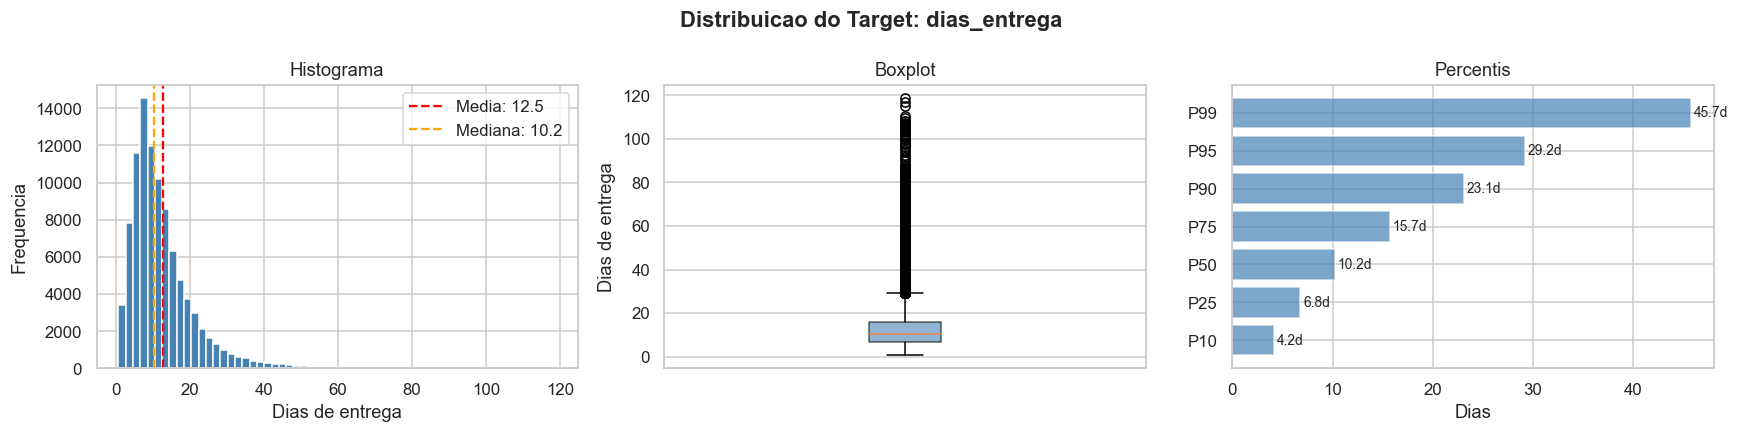

Media:   12.5 dias
Mediana: 10.2 dias
Desvio:  9.0 dias


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Distribuicao do Target: dias_entrega", fontweight='bold')

# Histograma
axes[0].hist(df['dias_entrega'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(df['dias_entrega'].mean(),   color='red',    linestyle='--', label=f"Media: {df['dias_entrega'].mean():.1f}")
axes[0].axvline(df['dias_entrega'].median(), color='orange', linestyle='--', label=f"Mediana: {df['dias_entrega'].median():.1f}")
axes[0].set_title("Histograma")
axes[0].set_xlabel("Dias de entrega")
axes[0].set_ylabel("Frequencia")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['dias_entrega'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title("Boxplot")
axes[1].set_ylabel("Dias de entrega")
axes[1].set_xticks([])

# Percentis
percentis = [10, 25, 50, 75, 90, 95, 99]
valores   = [df['dias_entrega'].quantile(p/100) for p in percentis]
axes[2].barh([f"P{p}" for p in percentis], valores, color='steelblue', alpha=0.7)
for i, v in enumerate(valores):
    axes[2].text(v + 0.3, i, f"{v:.1f}d", va='center', fontsize=9)
axes[2].set_title("Percentis")
axes[2].set_xlabel("Dias")

plt.tight_layout()
plt.show()

print(f"Media:   {df['dias_entrega'].mean():.1f} dias")
print(f"Mediana: {df['dias_entrega'].median():.1f} dias")
print(f"Desvio:  {df['dias_entrega'].std():.1f} dias")

## 4. Sazonalidade

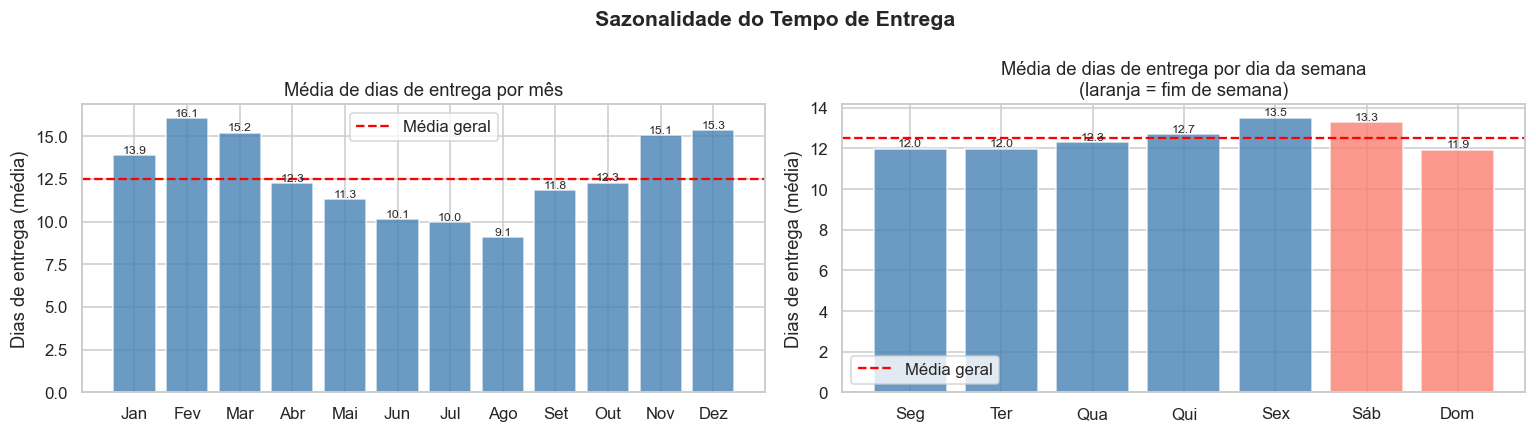

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Sazonalidade do Tempo de Entrega", fontsize=14, fontweight='bold')

# --- Por mês ---
meses_nome = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
media_mes  = df.groupby('mes_compra')['dias_entrega'].mean()
axes[0].bar(media_mes.index, media_mes.values, color='steelblue', alpha=0.8)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses_nome)
axes[0].axhline(df['dias_entrega'].mean(), color='red', linestyle='--', label='Média geral')
axes[0].set_title("Média de dias de entrega por mês")
axes[0].set_ylabel("Dias de entrega (média)")
axes[0].legend()
for i, v in zip(media_mes.index, media_mes.values):
    axes[0].text(i, v + 0.1, f"{v:.1f}", ha='center', fontsize=8)

# --- Por dia da semana ---
dias_nome   = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']
media_dia   = df.groupby('dia_semana_compra')['dias_entrega'].mean()
cores       = ['salmon' if i >= 5 else 'steelblue' for i in media_dia.index]
axes[1].bar(media_dia.index, media_dia.values, color=cores, alpha=0.8)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dias_nome)
axes[1].axhline(df['dias_entrega'].mean(), color='red', linestyle='--', label='Média geral')
axes[1].set_title("Média de dias de entrega por dia da semana\n(laranja = fim de semana)")
axes[1].set_ylabel("Dias de entrega (média)")
axes[1].legend()
for i, v in zip(media_dia.index, media_dia.values):
    axes[1].text(i, v + 0.1, f"{v:.1f}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 5. Analise Geografica

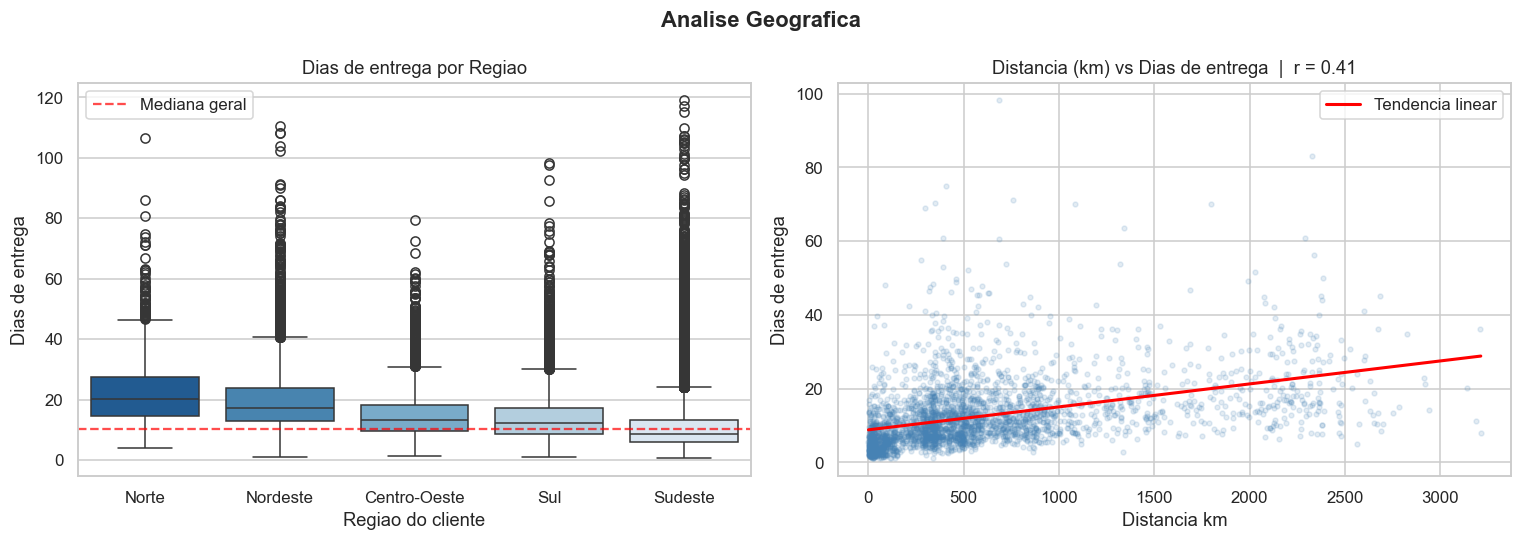

                    mean  median  count
mesmo_estado                           
Estados diferentes  15.1    12.8  61719
Mesmo estado         7.9     6.5  34693


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Analise Geografica", fontweight='bold')

# Por regiao
ordem_regioes = df.groupby('regiao_cliente')['dias_entrega'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='regiao_cliente', y='dias_entrega',
            order=ordem_regioes, palette='Blues_r', ax=axes[0])
axes[0].set_title("Dias de entrega por Regiao")
axes[0].set_xlabel("Regiao do cliente")
axes[0].set_ylabel("Dias de entrega")
axes[0].axhline(df['dias_entrega'].median(), color='red', linestyle='--', alpha=0.7, label='Mediana geral')
axes[0].legend()

# Distancia vs dias_entrega
amostra = df.sample(3000, random_state=42)
axes[1].scatter(amostra['distancia_km'], amostra['dias_entrega'], alpha=0.15, color='steelblue', s=10)
z = np.polyfit(amostra['distancia_km'], amostra['dias_entrega'], 1)
p = np.poly1d(z)
x_line = np.linspace(amostra['distancia_km'].min(), amostra['distancia_km'].max(), 200)
axes[1].plot(x_line, p(x_line), color='red', linewidth=2, label='Tendencia linear')
corr = amostra[['distancia_km','dias_entrega']].corr().iloc[0,1]
axes[1].set_title(f"Distancia (km) vs Dias de entrega  |  r = {corr:.2f}")
axes[1].set_xlabel("Distancia km")
axes[1].set_ylabel("Dias de entrega")
axes[1].legend()

plt.tight_layout()
plt.show()

print(df.groupby('mesmo_estado')['dias_entrega'].agg(['mean','median','count']).rename(
    index={0: 'Estados diferentes', 1: 'Mesmo estado'}
).round(1))

## 6. Categorias de Produto

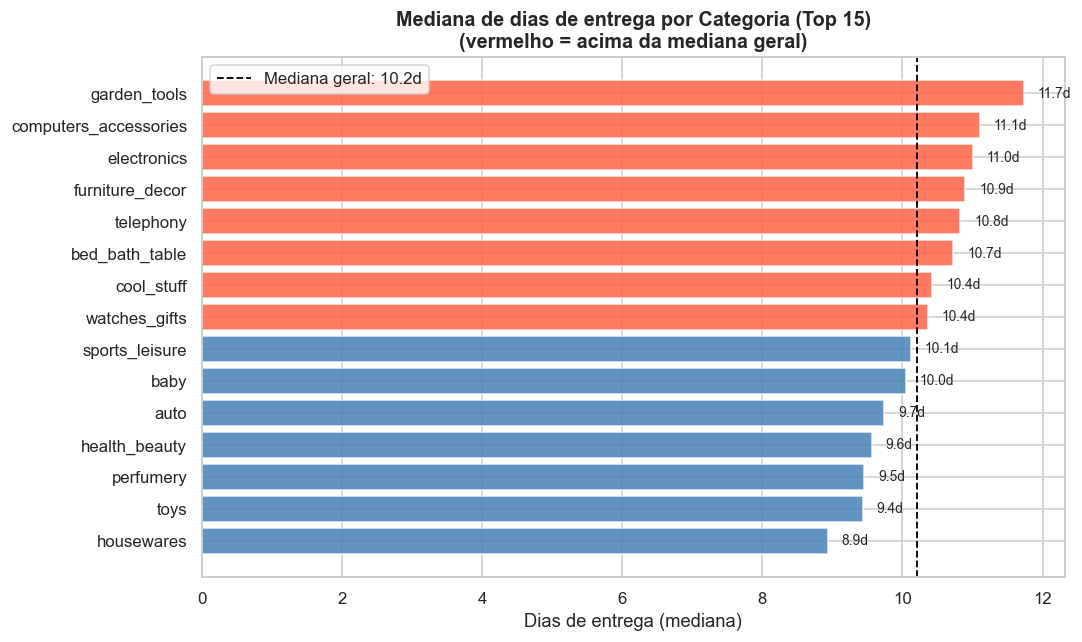

In [7]:
# Top 15 categorias com mais pedidos
top_cats = df['categoria_produto'].value_counts().head(15).index
df_cats  = df[df['categoria_produto'].isin(top_cats)]

media_cat = df_cats.groupby('categoria_produto')['dias_entrega'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(media_cat.index, media_cat.values,
               color=['tomato' if v > df['dias_entrega'].median() else 'steelblue' for v in media_cat.values],
               alpha=0.85)
ax.axvline(df['dias_entrega'].median(), color='black', linestyle='--', linewidth=1.2, label=f"Mediana geral: {df['dias_entrega'].median():.1f}d")
for bar, v in zip(bars, media_cat.values):
    ax.text(v + 0.2, bar.get_y() + bar.get_height()/2, f"{v:.1f}d", va='center', fontsize=9)
ax.set_title("Mediana de dias de entrega por Categoria (Top 15)\n(vermelho = acima da mediana geral)", fontsize=13, fontweight='bold')
ax.set_xlabel("Dias de entrega (mediana)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Analise do Vendedor

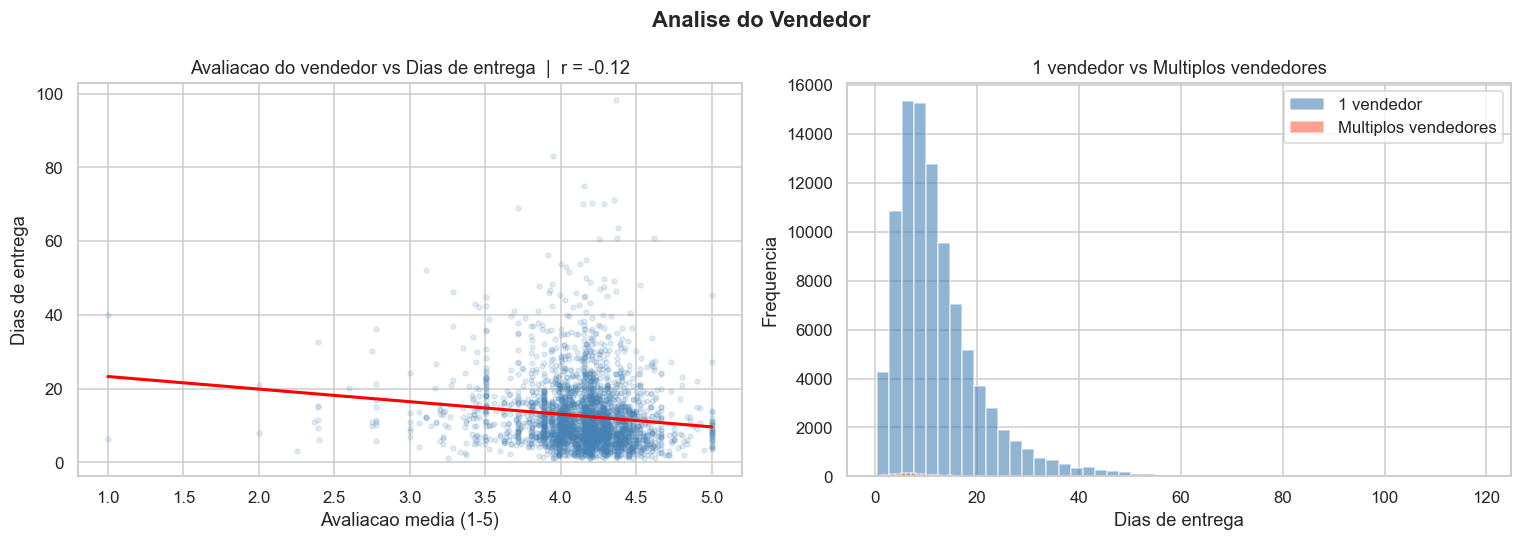

                      mean  median  count
multiplos_vendedores                     
1 vendedor            12.5    10.2  95137
Multiplos vendedores   9.1     7.9   1275


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Analise do Vendedor", fontweight='bold')

# Avaliacao do vendedor vs dias_entrega
amostra = df.sample(3000, random_state=42)
axes[0].scatter(amostra['media_avaliacao_vendedor'], amostra['dias_entrega'],
                alpha=0.15, color='steelblue', s=10)
z = np.polyfit(amostra['media_avaliacao_vendedor'], amostra['dias_entrega'], 1)
p = np.poly1d(z)
x_line = np.linspace(amostra['media_avaliacao_vendedor'].min(), amostra['media_avaliacao_vendedor'].max(), 100)
axes[0].plot(x_line, p(x_line), color='red', linewidth=2)
corr = amostra[['media_avaliacao_vendedor','dias_entrega']].corr().iloc[0,1]
axes[0].set_title(f"Avaliacao do vendedor vs Dias de entrega  |  r = {corr:.2f}")
axes[0].set_xlabel("Avaliacao media (1-5)")
axes[0].set_ylabel("Dias de entrega")

# 1 vendedor vs multiplos
df[df['multiplos_vendedores']==0]['dias_entrega'].plot.hist(bins=50, alpha=0.6, color='steelblue',
                                                             label='1 vendedor', ax=axes[1])
df[df['multiplos_vendedores']==1]['dias_entrega'].plot.hist(bins=50, alpha=0.6, color='tomato',
                                                             label='Multiplos vendedores', ax=axes[1])
axes[1].set_title("1 vendedor vs Multiplos vendedores")
axes[1].set_xlabel("Dias de entrega")
axes[1].set_ylabel("Frequencia")
axes[1].legend()

plt.tight_layout()
plt.show()

print(df.groupby('multiplos_vendedores')['dias_entrega'].agg(['mean','median','count']).rename(
    index={0: '1 vendedor', 1: 'Multiplos vendedores'}
).round(1))

## 8. Matriz de Correlacao

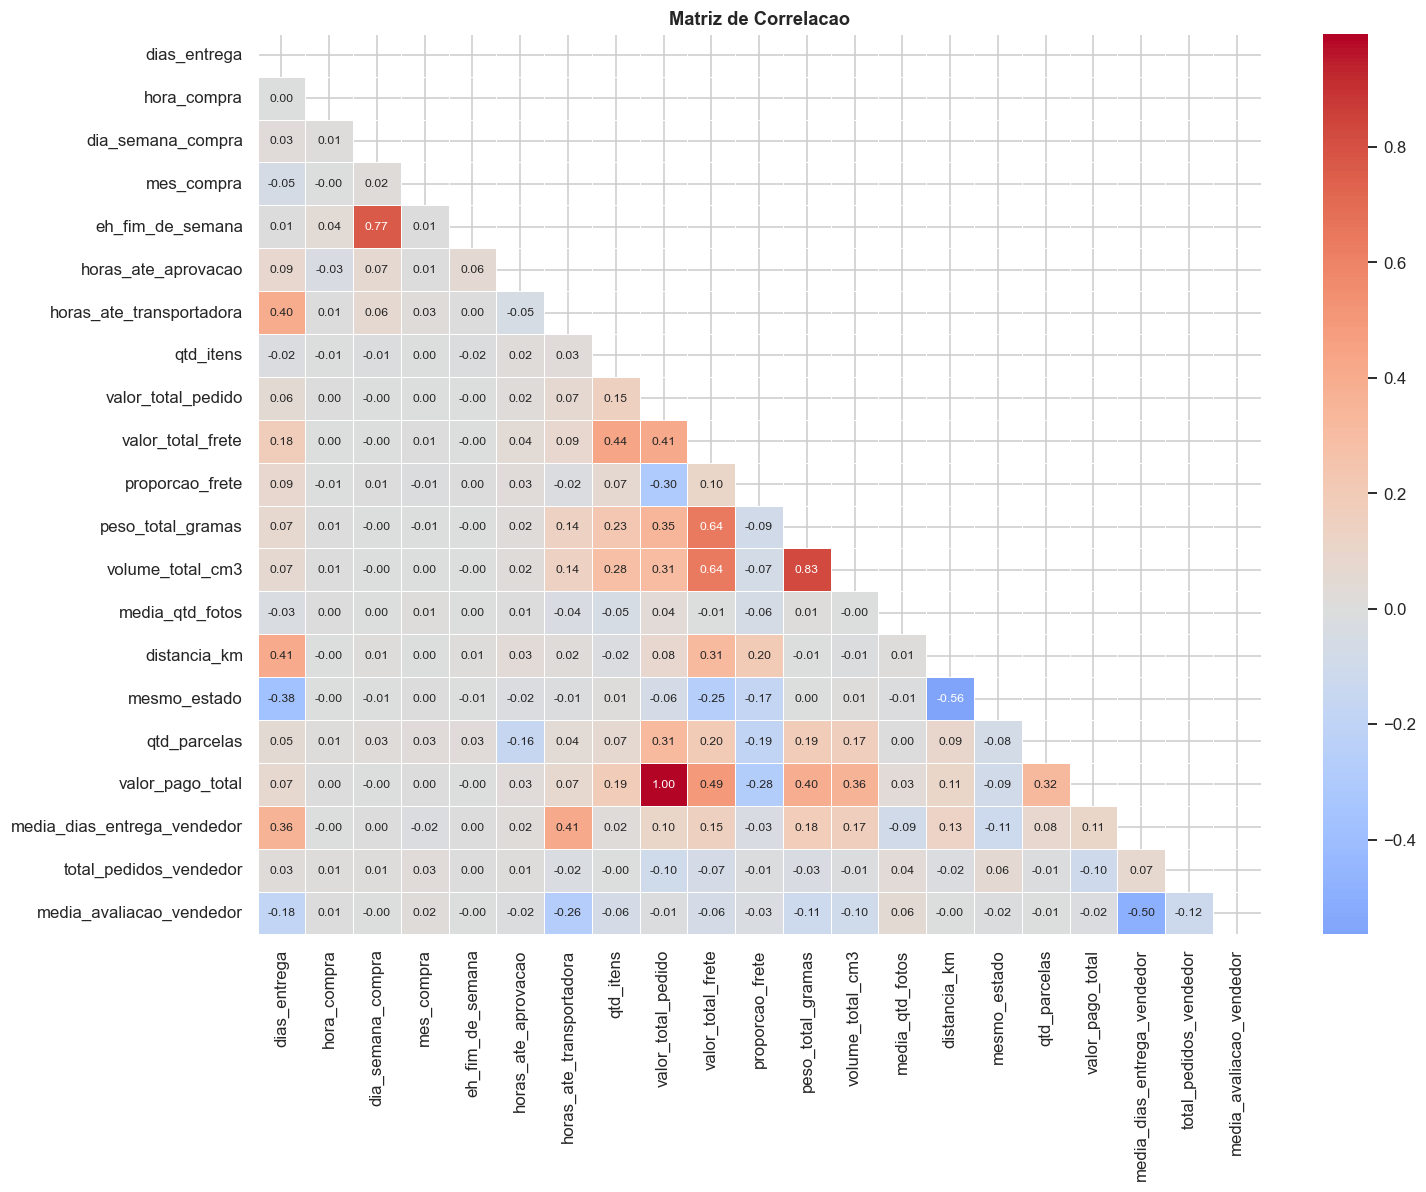


Correlacao com dias_entrega:
  distancia_km                        +0.409  ||||||||
  horas_ate_transportadora            +0.402  ||||||||
  mesmo_estado                        -0.381  |||||||
  media_dias_entrega_vendedor         +0.358  |||||||
  media_avaliacao_vendedor            -0.180  |||
  valor_total_frete                   +0.175  |||
  proporcao_frete                     +0.086  |
  horas_ate_aprovacao                 +0.086  |
  peso_total_gramas                   +0.074  |
  valor_pago_total                    +0.070  |
  volume_total_cm3                    +0.065  |
  valor_total_pedido                  +0.055  |
  mes_compra                          -0.055  |
  qtd_parcelas                        +0.054  |
  dia_semana_compra                   +0.032  
  media_qtd_fotos                     -0.028  
  total_pedidos_vendedor              +0.027  
  qtd_itens                           -0.020  
  eh_fim_de_semana                    +0.005  
  hora_compra                    

In [9]:
colunas_num = [
    'dias_entrega', 'hora_compra', 'dia_semana_compra', 'mes_compra', 'eh_fim_de_semana',
    'horas_ate_aprovacao', 'horas_ate_transportadora',
    'qtd_itens', 'valor_total_pedido', 'valor_total_frete', 'proporcao_frete',
    'peso_total_gramas', 'volume_total_cm3', 'media_qtd_fotos',
    'distancia_km', 'mesmo_estado',
    'qtd_parcelas', 'valor_pago_total',
    'media_dias_entrega_vendedor', 'total_pedidos_vendedor', 'media_avaliacao_vendedor'
]

corr_matrix = df[colunas_num].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={"size": 8})
ax.set_title("Matriz de Correlacao", fontweight='bold')
plt.tight_layout()
plt.show()

# Correlacao com o target
print("\nCorrelacao com dias_entrega:")
corr_target = corr_matrix['dias_entrega'].drop('dias_entrega').sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    barra = "|" * int(abs(val) * 20)
    sinal = "+" if val > 0 else "-"
    print(f"  {feat:<35s} {sinal}{abs(val):.3f}  {barra}")

## 9. Analise de Pagamento

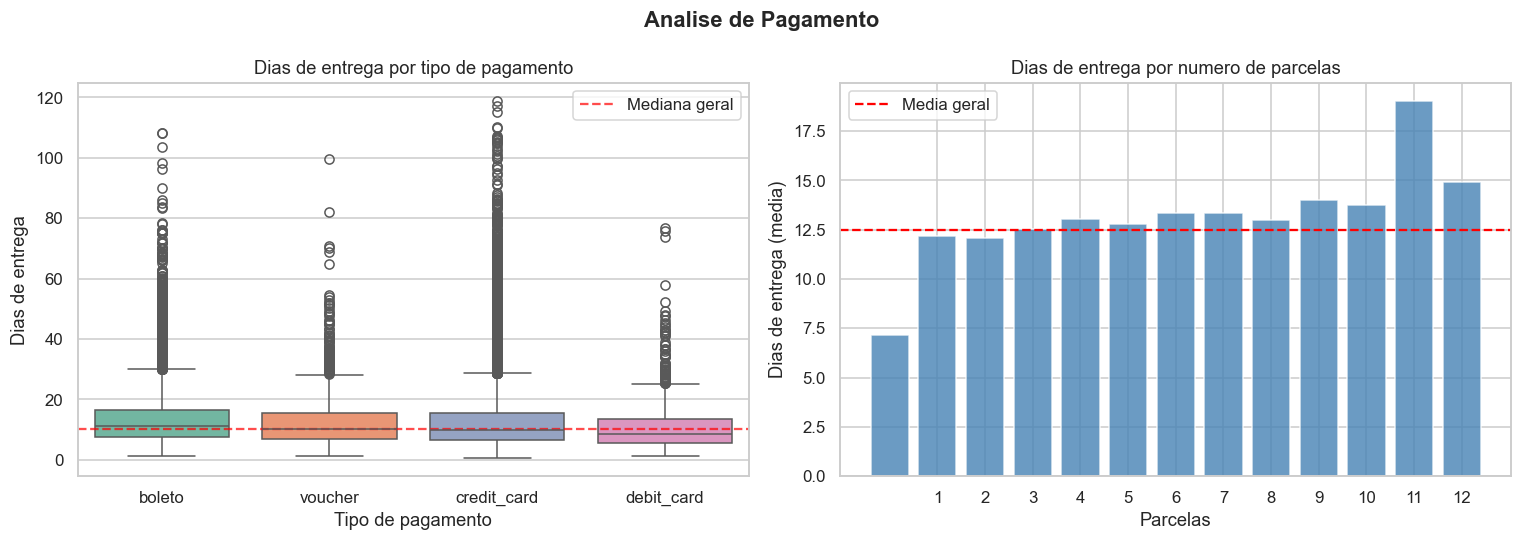

                mean  median  count
tipo_pagamento                     
boleto          13.4    11.3  19169
credit_card     12.3    10.0  73900
voucher         12.3    10.2   1859
debit_card      10.8     8.5   1483


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Analise de Pagamento", fontweight='bold')

# Por tipo de pagamento
ordem_pag = df.groupby('tipo_pagamento')['dias_entrega'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='tipo_pagamento', y='dias_entrega',
            order=ordem_pag, palette='Set2', ax=axes[0])
axes[0].axhline(df['dias_entrega'].median(), color='red', linestyle='--', alpha=0.7, label='Mediana geral')
axes[0].set_title("Dias de entrega por tipo de pagamento")
axes[0].set_xlabel("Tipo de pagamento")
axes[0].set_ylabel("Dias de entrega")
axes[0].legend()

# Por numero de parcelas
parcelas_validas = df[df['qtd_parcelas'] <= 12]
media_parcelas   = parcelas_validas.groupby('qtd_parcelas')['dias_entrega'].mean()
axes[1].bar(media_parcelas.index, media_parcelas.values, color='steelblue', alpha=0.8)
axes[1].axhline(df['dias_entrega'].mean(), color='red', linestyle='--', label='Media geral')
axes[1].set_title("Dias de entrega por numero de parcelas")
axes[1].set_xlabel("Parcelas")
axes[1].set_ylabel("Dias de entrega (media)")
axes[1].set_xticks(range(1, 13))
axes[1].legend()

plt.tight_layout()
plt.show()

print(df.groupby('tipo_pagamento')['dias_entrega'].agg(['mean','median','count']).round(1).sort_values('mean', ascending=False))

## 10. Conclusoes

In [11]:
print("""
CONCLUSOES DA ANALISE EXPLORATORIA
===================================

TARGET (dias_entrega)
  - Distribuicao assimetrica a direita
  - Mediana: ~12 dias | Media: ~13 dias
  - 90% dos pedidos chegam em ate ~25 dias

GEOGRAFIA (fator mais relevante)
  - Norte e Nordeste tem entregas mais lentas
  - Distancia em km tem correlacao positiva com dias_entrega
  - Pedidos no mesmo estado chegam mais rapido

VENDEDOR
  - Vendedores bem avaliados entregam mais rapido
  - Multiplos vendedores = pedidos mais lentos

SAZONALIDADE
  - Pedidos de fim de semana demoram levemente mais
  - Alguns meses apresentam variacao relevante

PAGAMENTO
  - Boleto tende a demorar mais (aguarda compensacao bancaria)

PROXIMO PASSO: Treinamento do modelo preditivo
  Features mais promissoras:
  distancia_km, media_dias_entrega_vendedor,
  horas_ate_transportadora, regiao_cliente,
  mesmo_estado, categoria_produto
""")


CONCLUSOES DA ANALISE EXPLORATORIA

TARGET (dias_entrega)
  - Distribuicao assimetrica a direita
  - Mediana: ~12 dias | Media: ~13 dias
  - 90% dos pedidos chegam em ate ~25 dias

GEOGRAFIA (fator mais relevante)
  - Norte e Nordeste tem entregas mais lentas
  - Distancia em km tem correlacao positiva com dias_entrega
  - Pedidos no mesmo estado chegam mais rapido

VENDEDOR
  - Vendedores bem avaliados entregam mais rapido
  - Multiplos vendedores = pedidos mais lentos

SAZONALIDADE
  - Pedidos de fim de semana demoram levemente mais
  - Alguns meses apresentam variacao relevante

PAGAMENTO
  - Boleto tende a demorar mais (aguarda compensacao bancaria)

PROXIMO PASSO: Treinamento do modelo preditivo
  Features mais promissoras:
  distancia_km, media_dias_entrega_vendedor,
  horas_ate_transportadora, regiao_cliente,
  mesmo_estado, categoria_produto



## 11. Distribuicao de Todas as Features Numericas

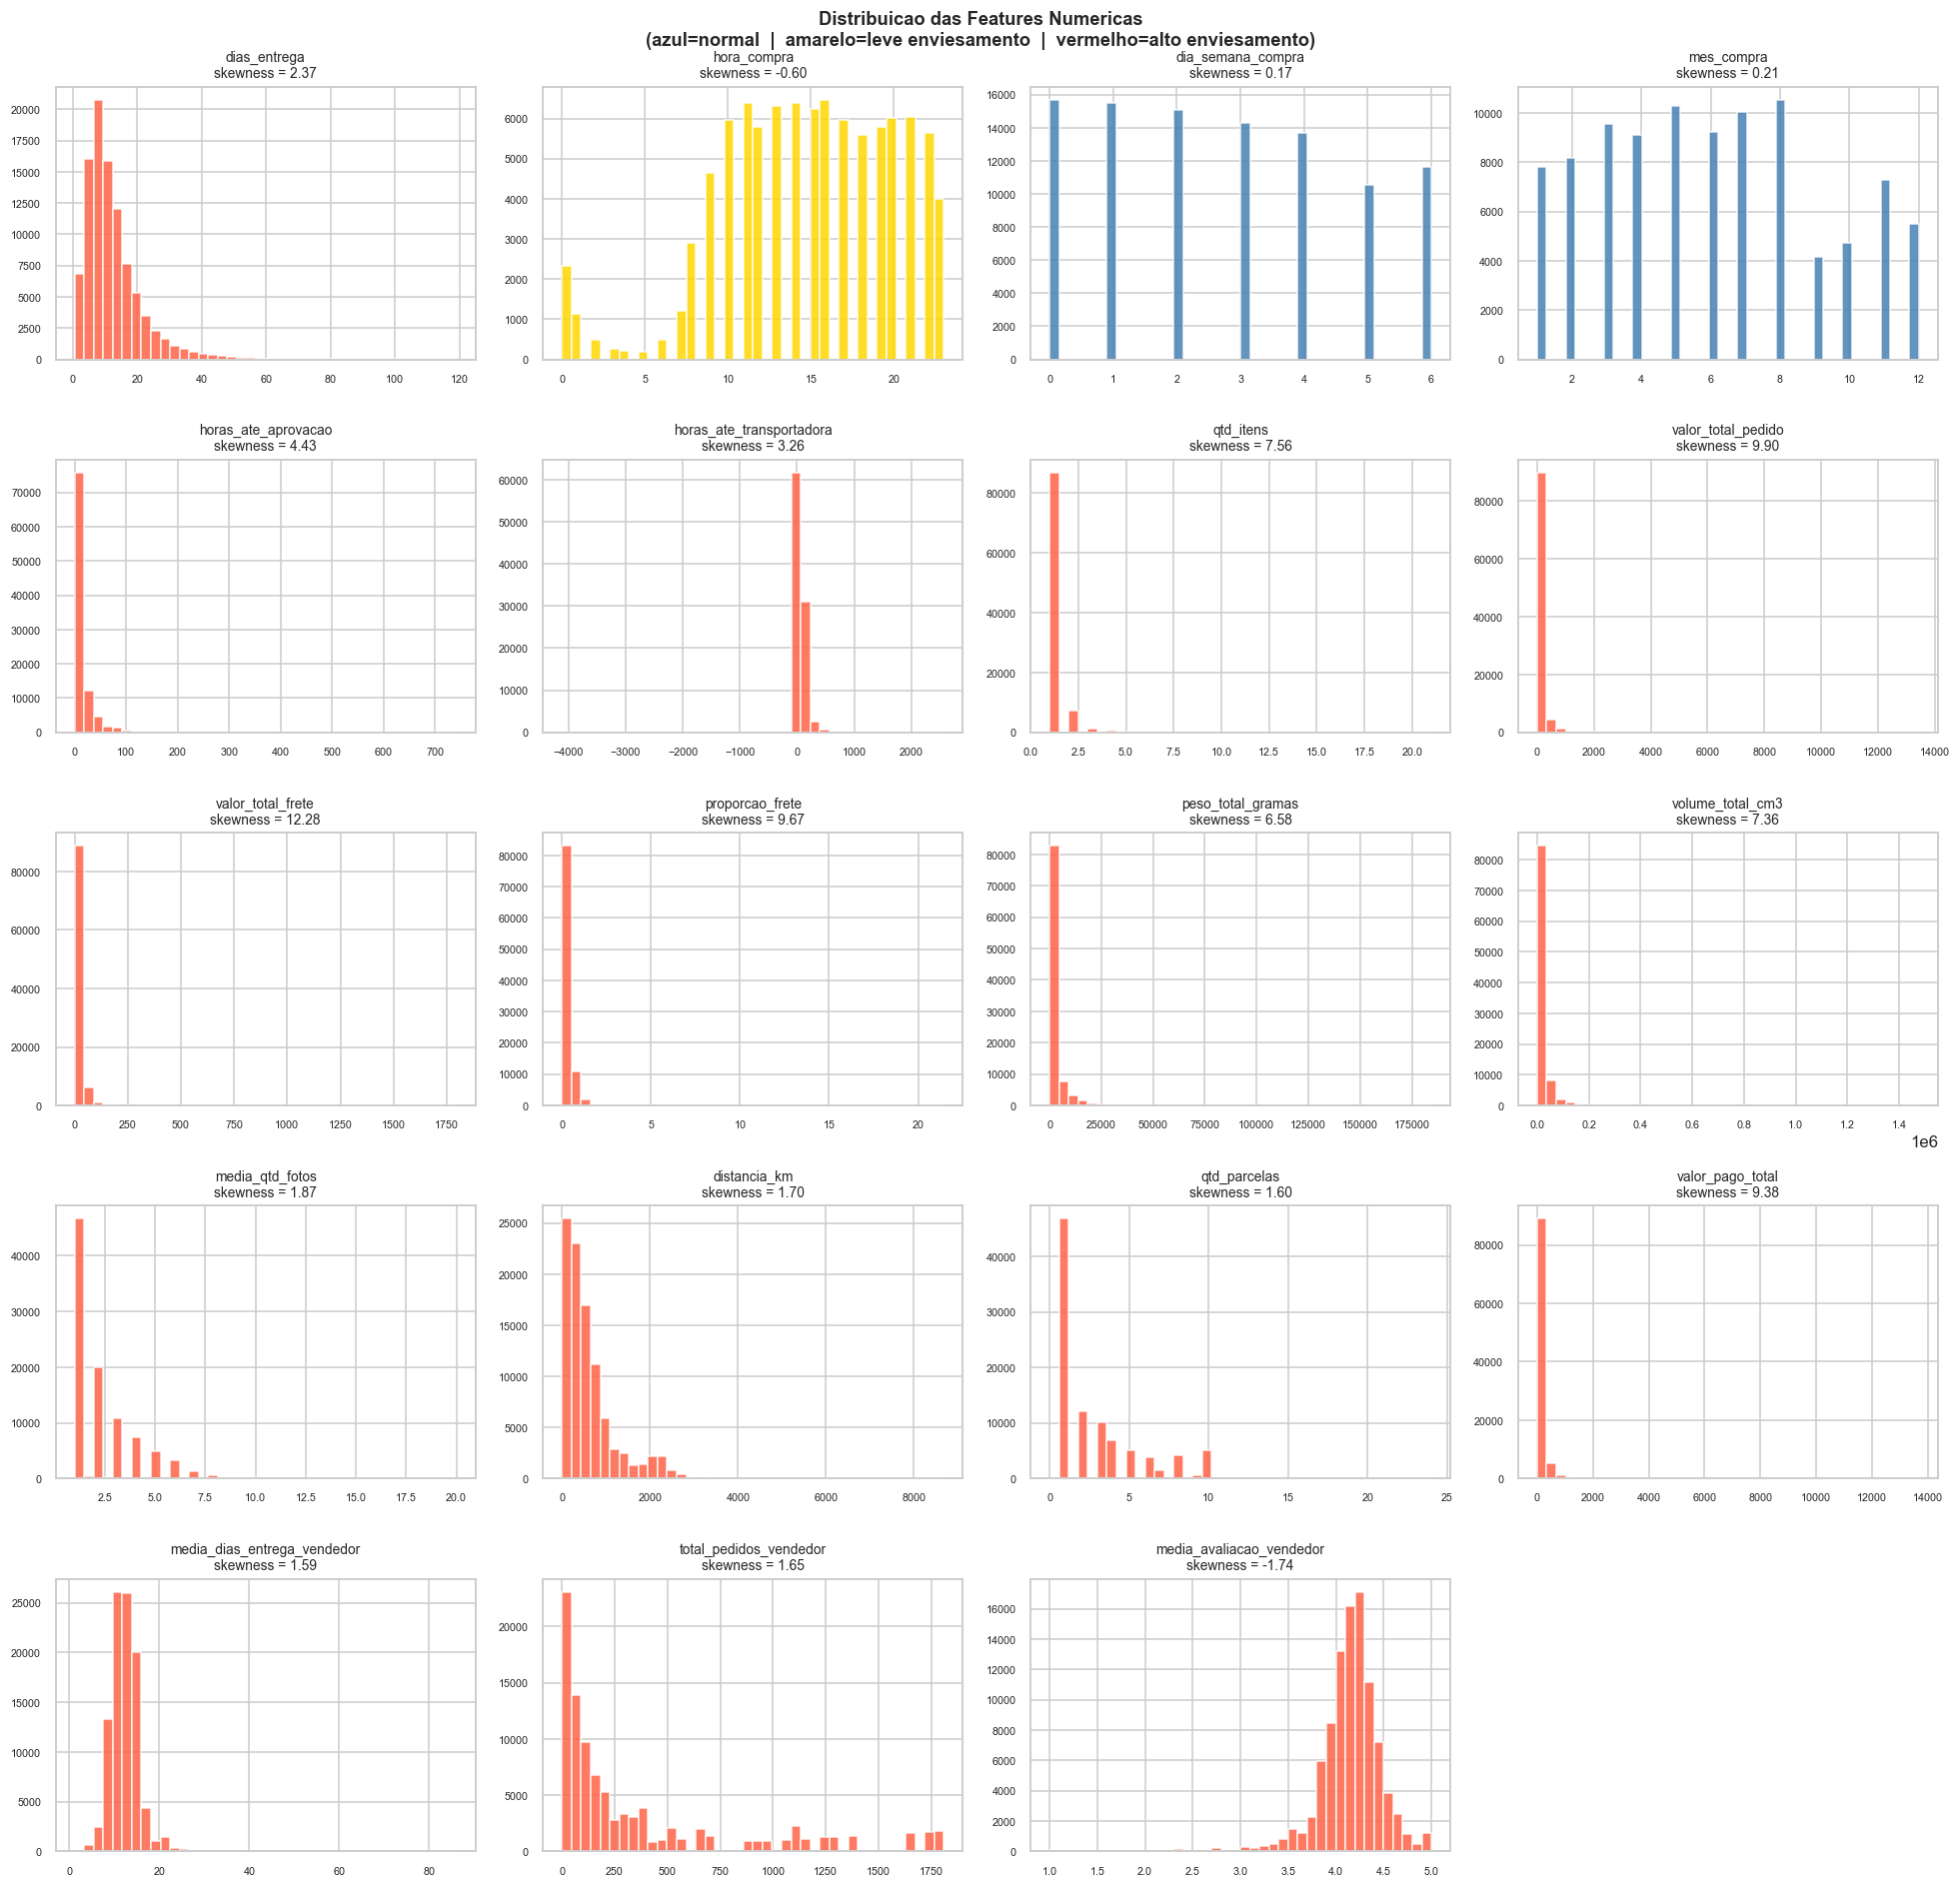


Ranking de assimetria:
                    Feature  Skewness                  Classificacao
          valor_total_frete 12.279388 ALTA - recomenda transformacao
         valor_total_pedido  9.896424 ALTA - recomenda transformacao
            proporcao_frete  9.671587 ALTA - recomenda transformacao
           valor_pago_total  9.376442 ALTA - recomenda transformacao
                  qtd_itens  7.557172 ALTA - recomenda transformacao
           volume_total_cm3  7.362153 ALTA - recomenda transformacao
          peso_total_gramas  6.575982 ALTA - recomenda transformacao
        horas_ate_aprovacao  4.425968 ALTA - recomenda transformacao
   horas_ate_transportadora  3.264907 ALTA - recomenda transformacao
               dias_entrega  2.367836 ALTA - recomenda transformacao
            media_qtd_fotos  1.866083 ALTA - recomenda transformacao
   media_avaliacao_vendedor -1.737752 ALTA - recomenda transformacao
               distancia_km  1.696178 ALTA - recomenda transformacao
     total

In [12]:
colunas_num = [
    'dias_entrega', 'hora_compra', 'dia_semana_compra', 'mes_compra',
    'horas_ate_aprovacao', 'horas_ate_transportadora',
    'qtd_itens', 'valor_total_pedido', 'valor_total_frete', 'proporcao_frete',
    'peso_total_gramas', 'volume_total_cm3', 'media_qtd_fotos',
    'distancia_km', 'qtd_parcelas', 'valor_pago_total',
    'media_dias_entrega_vendedor', 'total_pedidos_vendedor', 'media_avaliacao_vendedor'
]

n_cols = 4
n_rows = -(-len(colunas_num) // n_cols)  # ceil division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(colunas_num):
    skew = df[col].skew()
    cor  = 'tomato' if abs(skew) > 1 else ('gold' if abs(skew) > 0.5 else 'steelblue')
    axes[i].hist(df[col].dropna(), bins=40, color=cor, edgecolor='white', alpha=0.85)
    axes[i].set_title(f"{col}\nskewness = {skew:.2f}", fontsize=9)
    axes[i].set_xlabel("")
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle("Distribuicao das Features Numericas\n(azul=normal  |  amarelo=leve enviesamento  |  vermelho=alto enviesamento)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabela de skewness
skew_df = pd.DataFrame({
    'Feature'  : colunas_num,
    'Skewness' : [df[c].skew() for c in colunas_num],
}).sort_values('Skewness', key=abs, ascending=False)

skew_df['Classificacao'] = skew_df['Skewness'].apply(
    lambda s: 'ALTA - recomenda transformacao' if abs(s) > 1
    else ('MODERADA' if abs(s) > 0.5 else 'NORMAL')
)
print("\nRanking de assimetria:")
print(skew_df.to_string(index=False))

## 12. Valores Faltantes

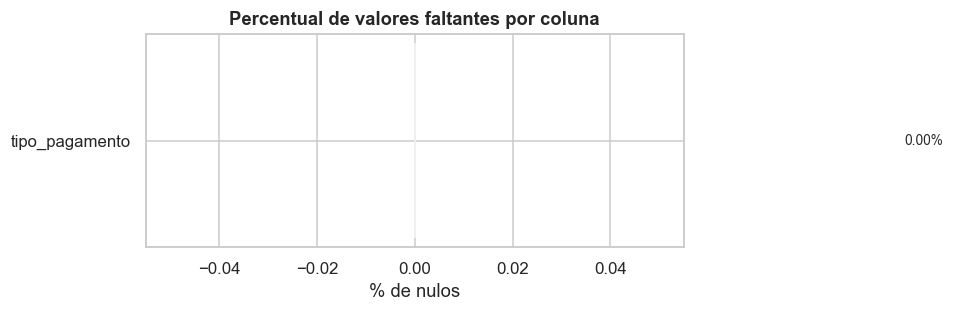


Tabela de valores faltantes:
                Nulos  Percentual                           Recomendacao
tipo_pagamento      1         0.0  Preencher com mediana (impacto baixo)

Total de celulas nulas: 1
Total de linhas com pelo menos 1 nulo: 1


In [13]:
missing = pd.DataFrame({
    'Nulos'     : df.isnull().sum(),
    'Percentual': (df.isnull().sum() / len(df) * 100).round(2),
}).query('Nulos > 0').sort_values('Percentual', ascending=False)

if missing.empty:
    print("Nenhum valor faltante encontrado no dataset.")
else:
    missing['Recomendacao'] = missing['Percentual'].apply(
        lambda p: 'Remover coluna'     if p > 50
        else ('Imputar com mediana'    if p > 5
        else  'Preencher com mediana (impacto baixo)')
    )

    fig, ax = plt.subplots(figsize=(10, max(3, len(missing) * 0.5)))
    bars = ax.barh(missing.index, missing['Percentual'], color='tomato', alpha=0.8)
    for bar, v in zip(bars, missing['Percentual']):
        ax.text(v + 0.1, bar.get_y() + bar.get_height()/2, f"{v:.2f}%", va='center', fontsize=9)
    ax.set_title("Percentual de valores faltantes por coluna", fontweight='bold')
    ax.set_xlabel("% de nulos")
    plt.tight_layout()
    plt.show()

    print("\nTabela de valores faltantes:")
    print(missing.to_string())

print(f"\nTotal de celulas nulas: {df.isnull().sum().sum()}")
print(f"Total de linhas com pelo menos 1 nulo: {df.isnull().any(axis=1).sum():,}")

## 13. Outliers por Feature

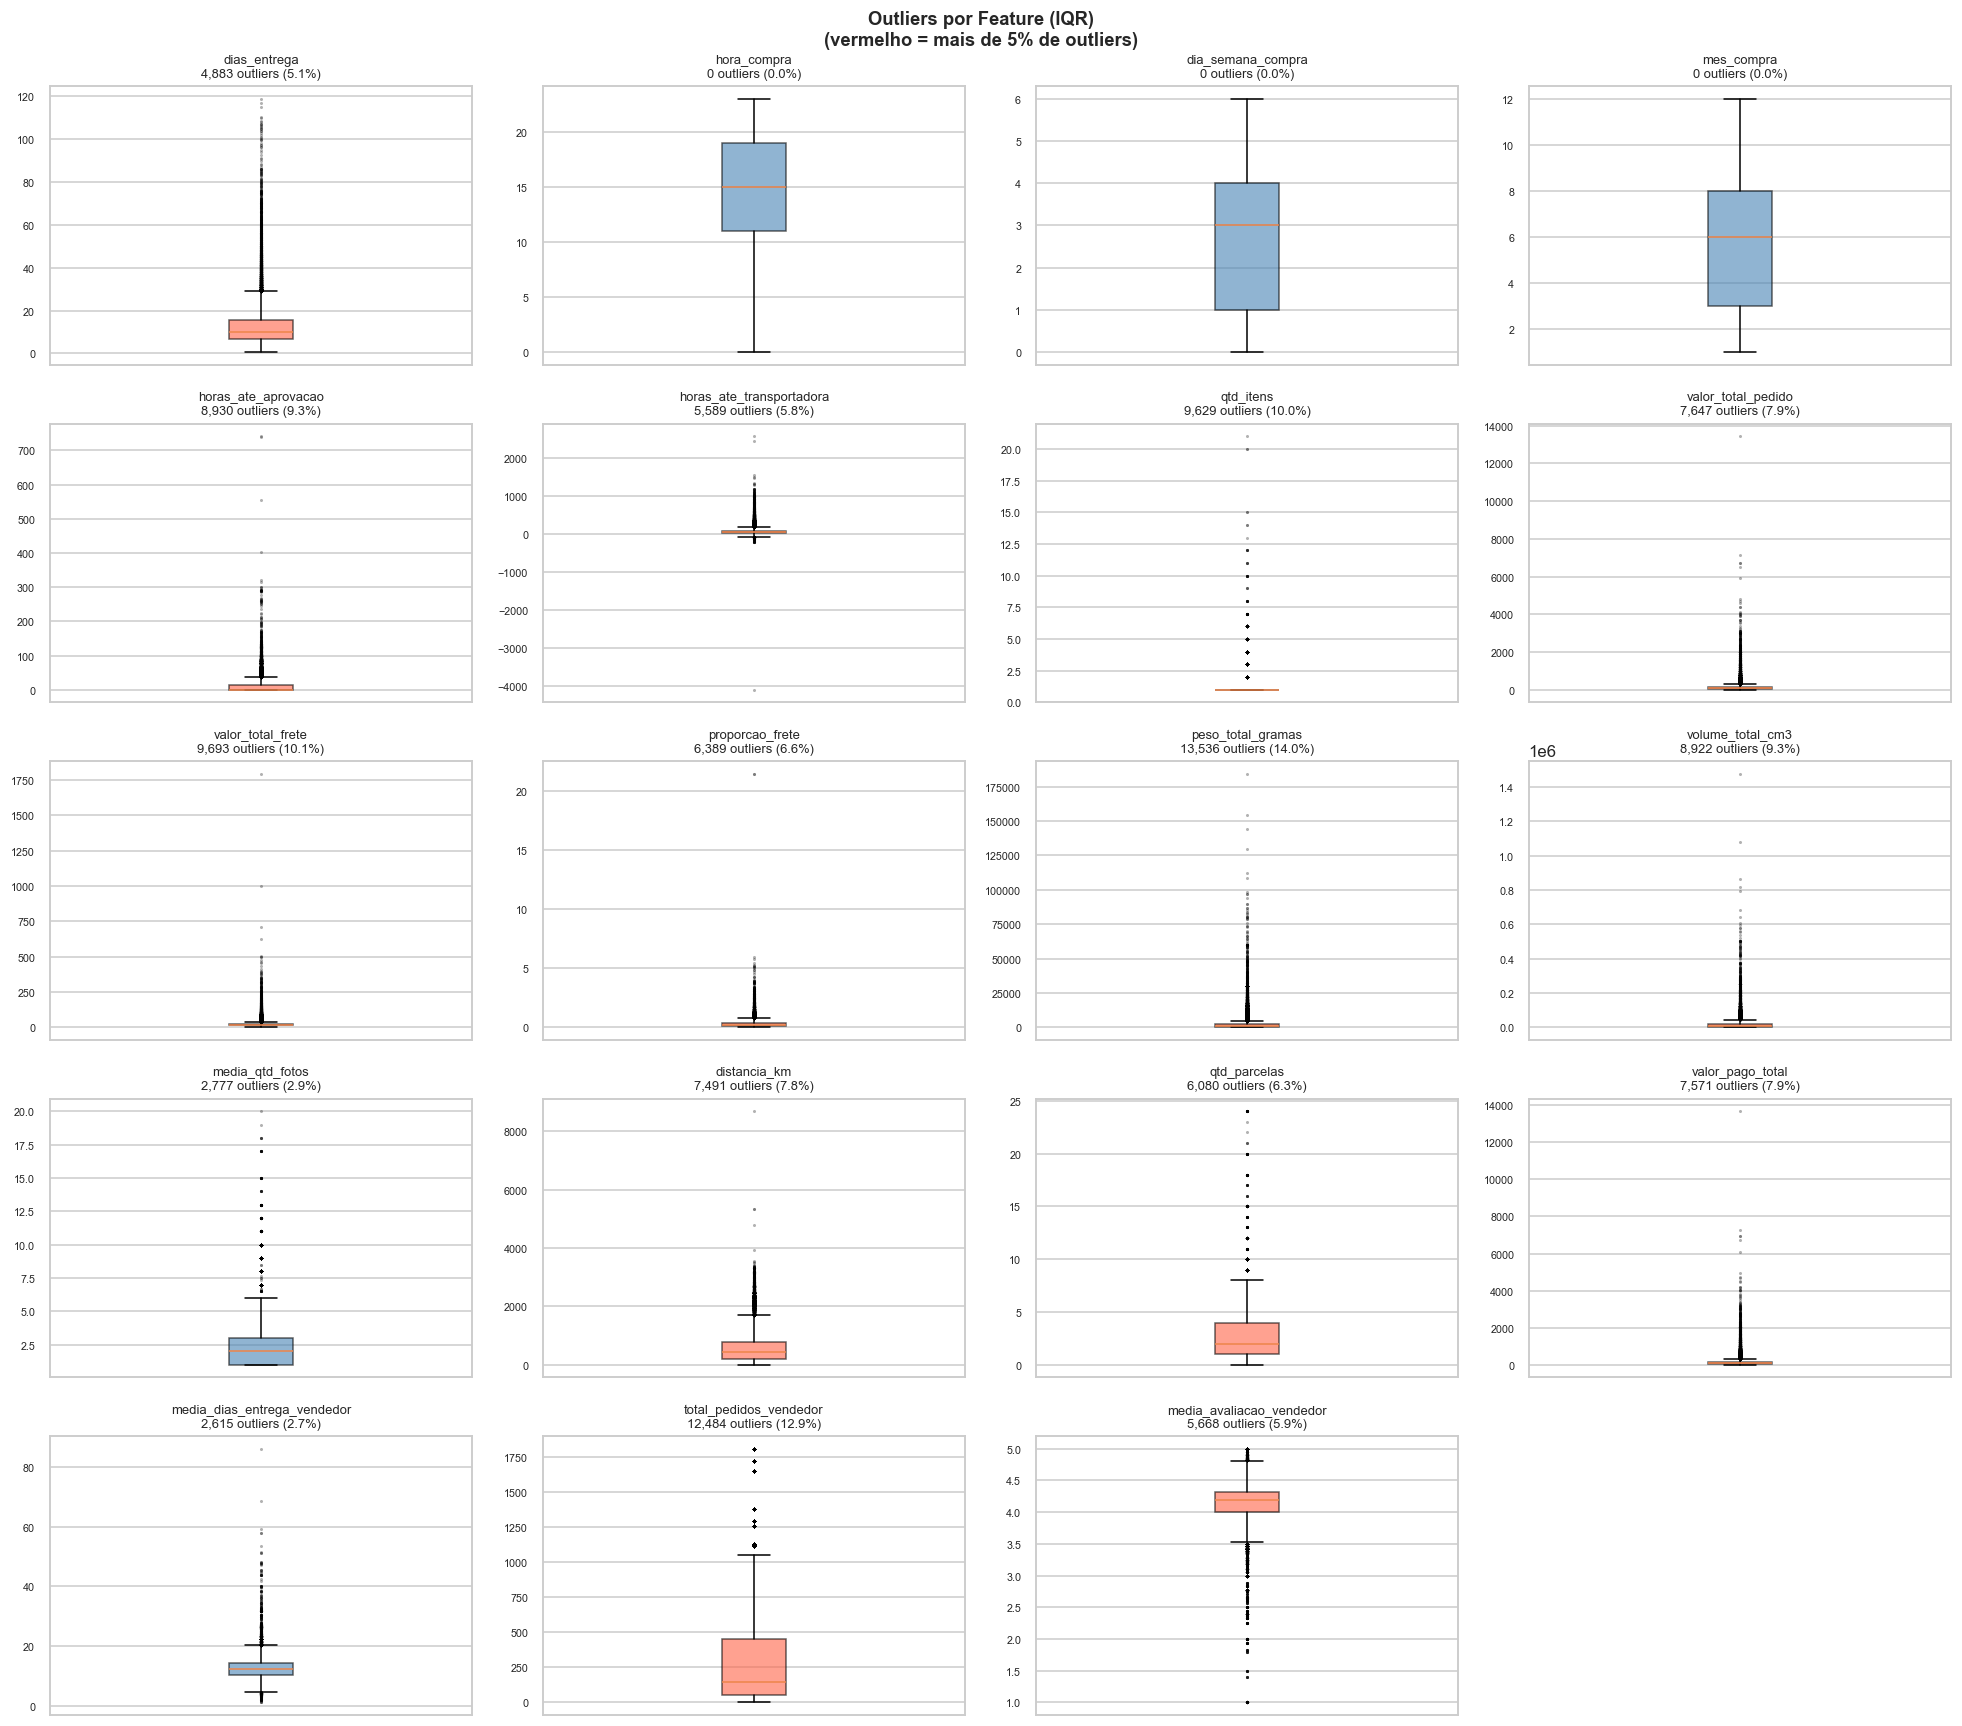


Ranking de outliers por feature:
                    Feature  Outliers  Percentual        Situacao
          peso_total_gramas     13536       14.04   CRITICO (>5%)
     total_pedidos_vendedor     12484       12.95   CRITICO (>5%)
          valor_total_frete      9693       10.05   CRITICO (>5%)
                  qtd_itens      9629        9.99   CRITICO (>5%)
        horas_ate_aprovacao      8930        9.26   CRITICO (>5%)
           volume_total_cm3      8922        9.25   CRITICO (>5%)
         valor_total_pedido      7647        7.93   CRITICO (>5%)
           valor_pago_total      7571        7.85   CRITICO (>5%)
               distancia_km      7491        7.77   CRITICO (>5%)
            proporcao_frete      6389        6.63   CRITICO (>5%)
               qtd_parcelas      6080        6.31   CRITICO (>5%)
   media_avaliacao_vendedor      5668        5.88   CRITICO (>5%)
   horas_ate_transportadora      5589        5.80   CRITICO (>5%)
               dias_entrega      4883     

In [14]:
n_cols = 4
n_rows = -(-len(colunas_num) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.2))
axes = axes.flatten()

outlier_info = []
for i, col in enumerate(colunas_num):
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr     = q3 - q1
    n_out   = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    pct_out = n_out / len(df) * 100
    cor     = 'tomato' if pct_out > 5 else 'steelblue'

    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=cor, alpha=0.6),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    axes[i].set_title(f"{col}\n{n_out:,} outliers ({pct_out:.1f}%)", fontsize=8.5)
    axes[i].set_xticks([])
    axes[i].tick_params(labelsize=7)
    outlier_info.append({'Feature': col, 'Outliers': n_out, 'Percentual': round(pct_out, 2)})

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle("Outliers por Feature (IQR)\n(vermelho = mais de 5% de outliers)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Ranking de outliers
out_df = pd.DataFrame(outlier_info).sort_values('Percentual', ascending=False)
out_df['Situacao'] = out_df['Percentual'].apply(
    lambda p: 'CRITICO (>5%)'   if p > 5
    else      ('MODERADO (1-5%)' if p > 1
    else       'OK (<1%)')
)
print("\nRanking de outliers por feature:")
print(out_df.to_string(index=False))

## 14. Distribuicao das Variaveis Categoricas

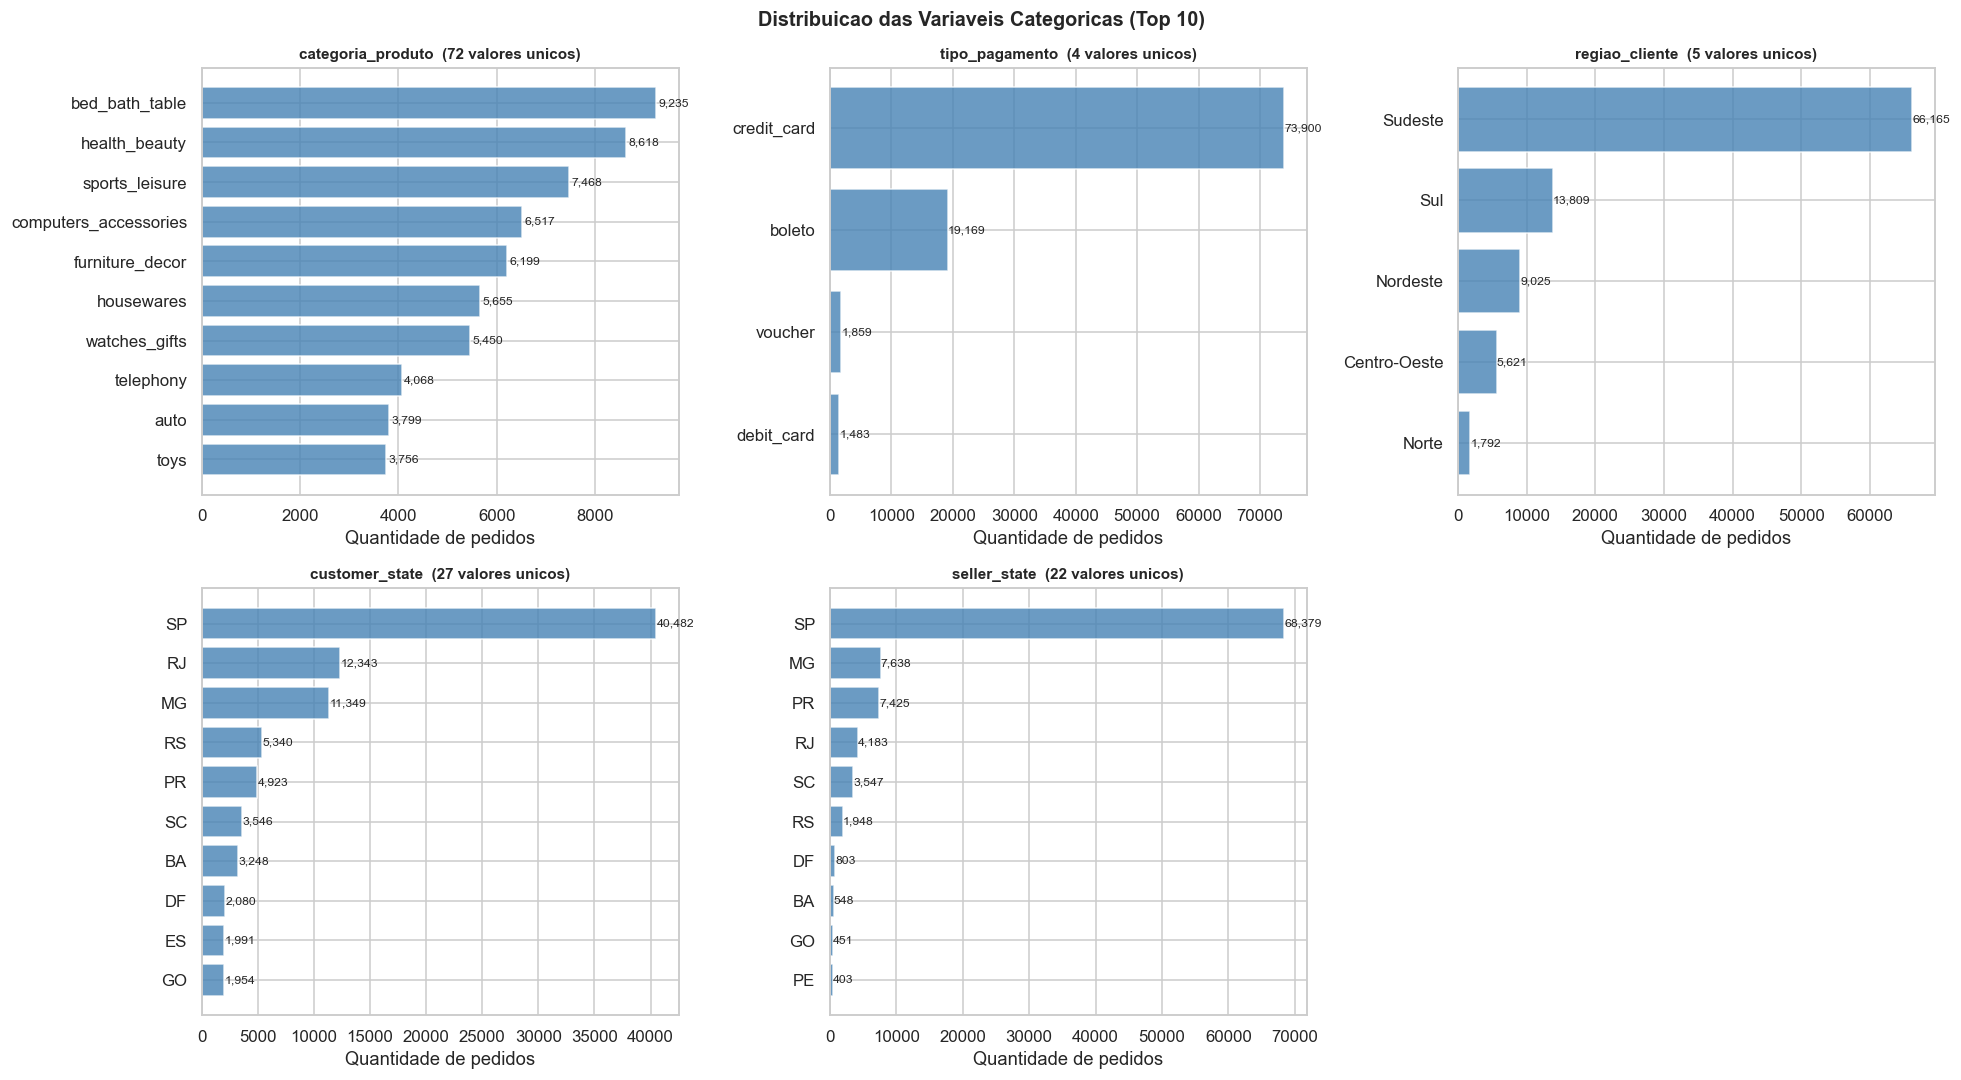


Resumo das variaveis categoricas:

[categoria_produto]  72 valores unicos
categoria_produto
bed_bath_table           9235
health_beauty            8618
sports_leisure           7468
computers_accessories    6517
furniture_decor          6199

[tipo_pagamento]  4 valores unicos
tipo_pagamento
credit_card    73900
boleto         19169
voucher         1859
debit_card      1483

[regiao_cliente]  5 valores unicos
regiao_cliente
Sudeste         66165
Sul             13809
Nordeste         9025
Centro-Oeste     5621
Norte            1792

[customer_state]  27 valores unicos
customer_state
SP    40482
RJ    12343
MG    11349
RS     5340
PR     4923

[seller_state]  22 valores unicos
seller_state
SP    68379
MG     7638
PR     7425
RJ     4183
SC     3547


In [15]:
colunas_cat = ['categoria_produto', 'tipo_pagamento', 'regiao_cliente',
               'customer_state', 'seller_state']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(colunas_cat):
    top10 = df[col].value_counts().head(10)
    axes[i].barh(top10.index[::-1], top10.values[::-1], color='steelblue', alpha=0.8)
    axes[i].set_title(f"{col}  ({df[col].nunique()} valores unicos)", fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Quantidade de pedidos")
    for bar, v in zip(axes[i].patches, top10.values[::-1]):
        axes[i].text(v + 50, bar.get_y() + bar.get_height()/2,
                     f"{v:,}", va='center', fontsize=8)

axes[-1].axis('off')
fig.suptitle("Distribuicao das Variaveis Categoricas (Top 10)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nResumo das variaveis categoricas:")
for col in colunas_cat:
    print(f"\n[{col}]  {df[col].nunique()} valores unicos")
    print(df[col].value_counts().head(5).to_string())

## 15. Ranking de Correlacao com o Target

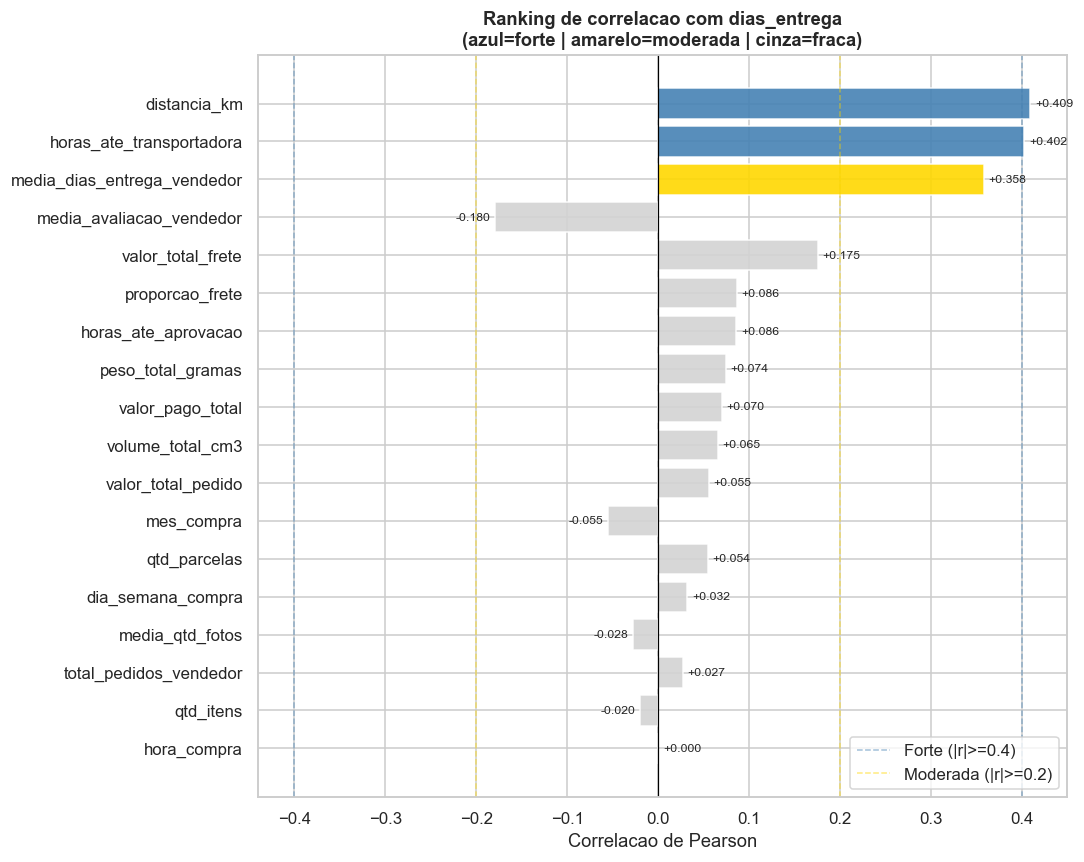


Ranking completo:
                    Feature  Correlacao    Forca
               distancia_km    0.408998    FORTE
   horas_ate_transportadora    0.402447    FORTE
media_dias_entrega_vendedor    0.358057 MODERADA
   media_avaliacao_vendedor   -0.179653    FRACA
          valor_total_frete    0.175244    FRACA
            proporcao_frete    0.086270    FRACA
        horas_ate_aprovacao    0.085918    FRACA
          peso_total_gramas    0.074427    FRACA
           valor_pago_total    0.070170    FRACA
           volume_total_cm3    0.065211    FRACA
         valor_total_pedido    0.055336    FRACA
                 mes_compra   -0.054939    FRACA
               qtd_parcelas    0.054188    FRACA
          dia_semana_compra    0.031817    FRACA
            media_qtd_fotos   -0.027602    FRACA
     total_pedidos_vendedor    0.026636    FRACA
                  qtd_itens   -0.019904    FRACA
                hora_compra    0.000206    FRACA


In [16]:
corr_target = (df[colunas_num]
               .corr()['dias_entrega']
               .drop('dias_entrega')
               .sort_values(key=abs, ascending=True))

cores = []
for v in corr_target.values:
    if abs(v) >= 0.4:   cores.append('steelblue')
    elif abs(v) >= 0.2: cores.append('gold')
    else:               cores.append('lightgray')

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(corr_target.index, corr_target.values, color=cores, alpha=0.9, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.4, color='steelblue', linewidth=1, linestyle='--', alpha=0.5, label='Forte (|r|>=0.4)')
ax.axvline(-0.4, color='steelblue', linewidth=1, linestyle='--', alpha=0.5)
ax.axvline( 0.2, color='gold',      linewidth=1, linestyle='--', alpha=0.5, label='Moderada (|r|>=0.2)')
ax.axvline(-0.2, color='gold',      linewidth=1, linestyle='--', alpha=0.5)
for bar, v in zip(bars, corr_target.values):
    ax.text(v + (0.005 if v >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f"{v:+.3f}", va='center', ha='left' if v >= 0 else 'right', fontsize=8)
ax.set_title("Ranking de correlacao com dias_entrega\n(azul=forte | amarelo=moderada | cinza=fraca)",
             fontweight='bold')
ax.set_xlabel("Correlacao de Pearson")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Tabela classificada
rank_df = pd.DataFrame({'Feature': corr_target.index, 'Correlacao': corr_target.values})
rank_df['Forca'] = rank_df['Correlacao'].apply(
    lambda v: 'FORTE'    if abs(v) >= 0.4
    else     ('MODERADA' if abs(v) >= 0.2
    else       'FRACA')
)
rank_df = rank_df.sort_values('Correlacao', key=abs, ascending=False)
print("\nRanking completo:")
print(rank_df.to_string(index=False))

## 16. Multicolinearidade

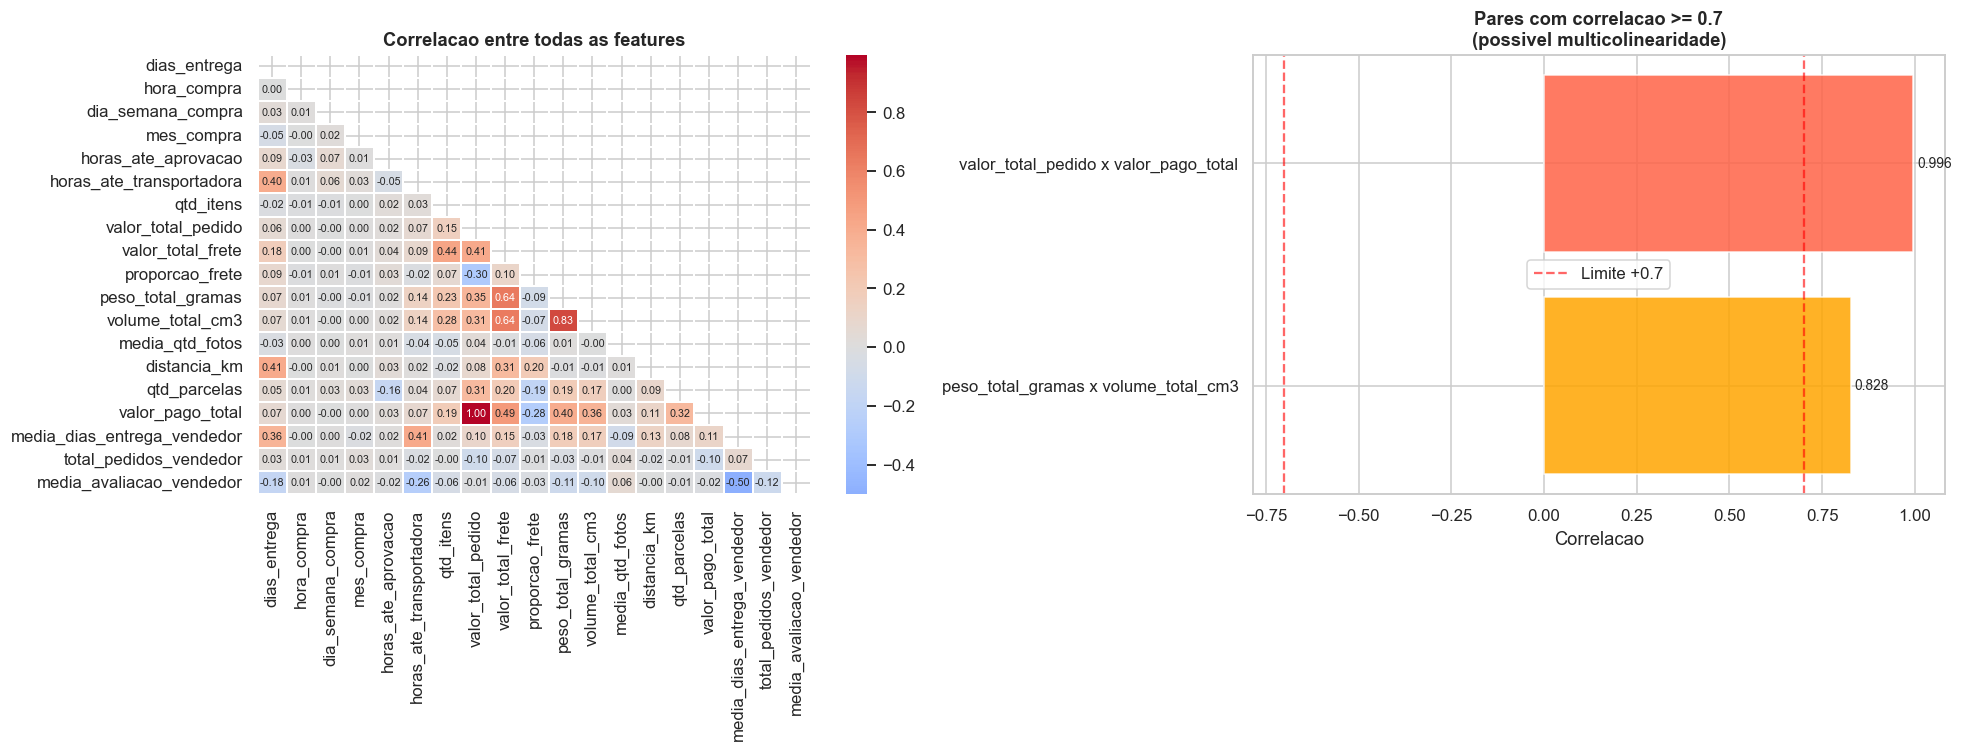


Pares de features com possivel multicolinearidade (|r| >= 0.7):
         Feature A        Feature B  Correlacao
valor_total_pedido valor_pago_total       0.996
 peso_total_gramas volume_total_cm3       0.828

Recomendacao: considere remover uma das features de cada par redundante.


In [17]:
corr_matrix = df[colunas_num].corr()

# Encontra pares com correlacao alta (excluindo diagonal e duplicatas)
pares = []
for i in range(len(colunas_num)):
    for j in range(i + 1, len(colunas_num)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= 0.7:
            pares.append({
                'Feature A'   : colunas_num[i],
                'Feature B'   : colunas_num[j],
                'Correlacao'  : round(val, 3),
                'Abs'         : round(abs(val), 3)
            })

# Heatmap focado nas features com alta correlacao entre si
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap geral com destaque
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt=".2f", linewidths=0.3,
            ax=axes[0], annot_kws={"size": 7})
axes[0].set_title("Correlacao entre todas as features", fontweight='bold')

# Grafico de pares com alta correlacao
if pares:
    pares_df = pd.DataFrame(pares).sort_values('Abs', ascending=True)
    labels   = [f"{r['Feature A']} x {r['Feature B']}" for _, r in pares_df.iterrows()]
    cores_p  = ['tomato' if abs(v) >= 0.9 else 'orange' for v in pares_df['Correlacao']]
    axes[1].barh(labels, pares_df['Correlacao'], color=cores_p, alpha=0.85)
    axes[1].axvline(0.7,  color='red',    linestyle='--', alpha=0.6, label='Limite +0.7')
    axes[1].axvline(-0.7, color='red',    linestyle='--', alpha=0.6)
    axes[1].set_title("Pares com correlacao >= 0.7\n(possivel multicolinearidade)", fontweight='bold')
    axes[1].set_xlabel("Correlacao")
    axes[1].legend()
    for bar, v in zip(axes[1].patches, pares_df['Correlacao']):
        axes[1].text(v + 0.01, bar.get_y() + bar.get_height()/2,
                     f"{v:.3f}", va='center', fontsize=9)
else:
    axes[1].text(0.5, 0.5, "Nenhum par com correlacao >= 0.7 encontrado",
                 ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

if pares:
    print("\nPares de features com possivel multicolinearidade (|r| >= 0.7):")
    print(pd.DataFrame(pares).sort_values('Abs', ascending=False).drop('Abs', axis=1).to_string(index=False))
    print("\nRecomendacao: considere remover uma das features de cada par redundante.")
else:
    print("Nenhum par com multicolinearidade critica encontrado.")

## 17. Analise Cruzada: Categoricas vs Target

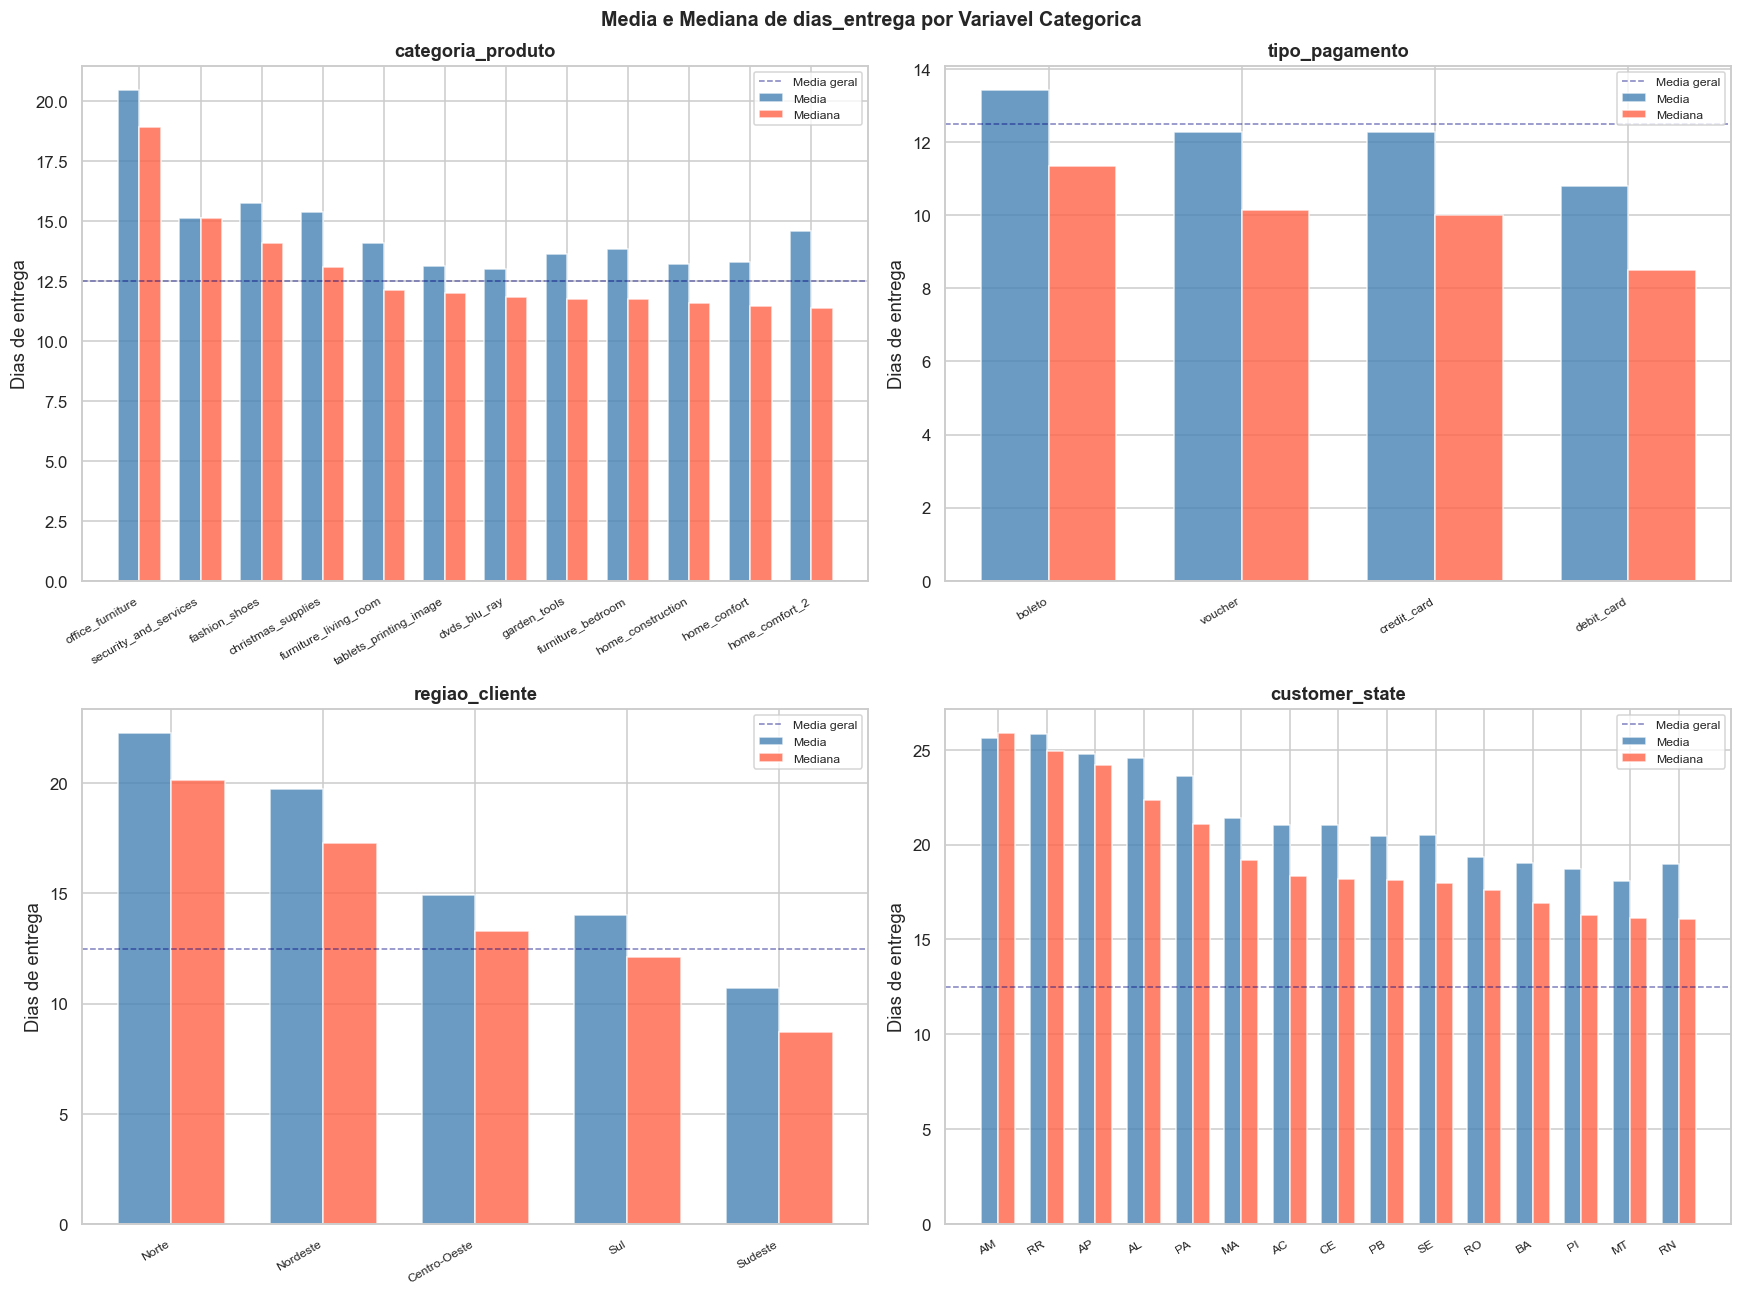


[categoria_produto]
                                         media  mediana  contagem
categoria_produto                                                
office_furniture                          20.4     18.9      1242
security_and_services                     15.1     15.1         2
fashion_shoes                             15.7     14.1       233
christmas_supplies                        15.4     13.1       125
furniture_living_room                     14.1     12.1       403
tablets_printing_image                    13.1     12.0        76
dvds_blu_ray                              13.0     11.8        55
garden_tools                              13.6     11.7      3408
furniture_bedroom                         13.8     11.7        88
home_construction                         13.2     11.6       459
home_confort                              13.3     11.5       345
home_comfort_2                            14.6     11.4        23
consoles_games                            13.6     11.2

In [18]:
cats_analise = {
    'categoria_produto': 12,
    'tipo_pagamento'   : 10,
    'regiao_cliente'   : 10,
    'customer_state'   : 15,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (col, top_n) in enumerate(cats_analise.items()):
    resumo = (df.groupby(col)['dias_entrega']
              .agg(media='mean', mediana='median', contagem='count')
              .sort_values('mediana', ascending=False)
              .head(top_n))

    x    = range(len(resumo))
    w    = 0.35
    ax   = axes[idx]
    bar1 = ax.bar([i - w/2 for i in x], resumo['media'],   width=w, label='Media',   color='steelblue', alpha=0.8)
    bar2 = ax.bar([i + w/2 for i in x], resumo['mediana'], width=w, label='Mediana', color='tomato',    alpha=0.8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(resumo.index, rotation=30, ha='right', fontsize=8)
    ax.axhline(df['dias_entrega'].mean(), color='navy', linestyle='--', alpha=0.5, linewidth=1, label='Media geral')
    ax.set_title(f"{col}", fontweight='bold')
    ax.set_ylabel("Dias de entrega")
    ax.legend(fontsize=8)

fig.suptitle("Media e Mediana de dias_entrega por Variavel Categorica", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabelas detalhadas
for col in cats_analise:
    print(f"\n[{col}]")
    tabela = (df.groupby(col)['dias_entrega']
              .agg(media='mean', mediana='median', contagem='count')
              .sort_values('mediana', ascending=False))
    tabela['media']   = tabela['media'].round(1)
    tabela['mediana'] = tabela['mediana'].round(1)
    print(tabela.to_string())

## 18. Pairplot das Top 5 Features

Top 5 features mais correlacionadas com dias_entrega:
  distancia_km                         r = +0.409
  horas_ate_transportadora             r = +0.402
  media_dias_entrega_vendedor          r = +0.358
  media_avaliacao_vendedor             r = -0.180
  valor_total_frete                    r = +0.175


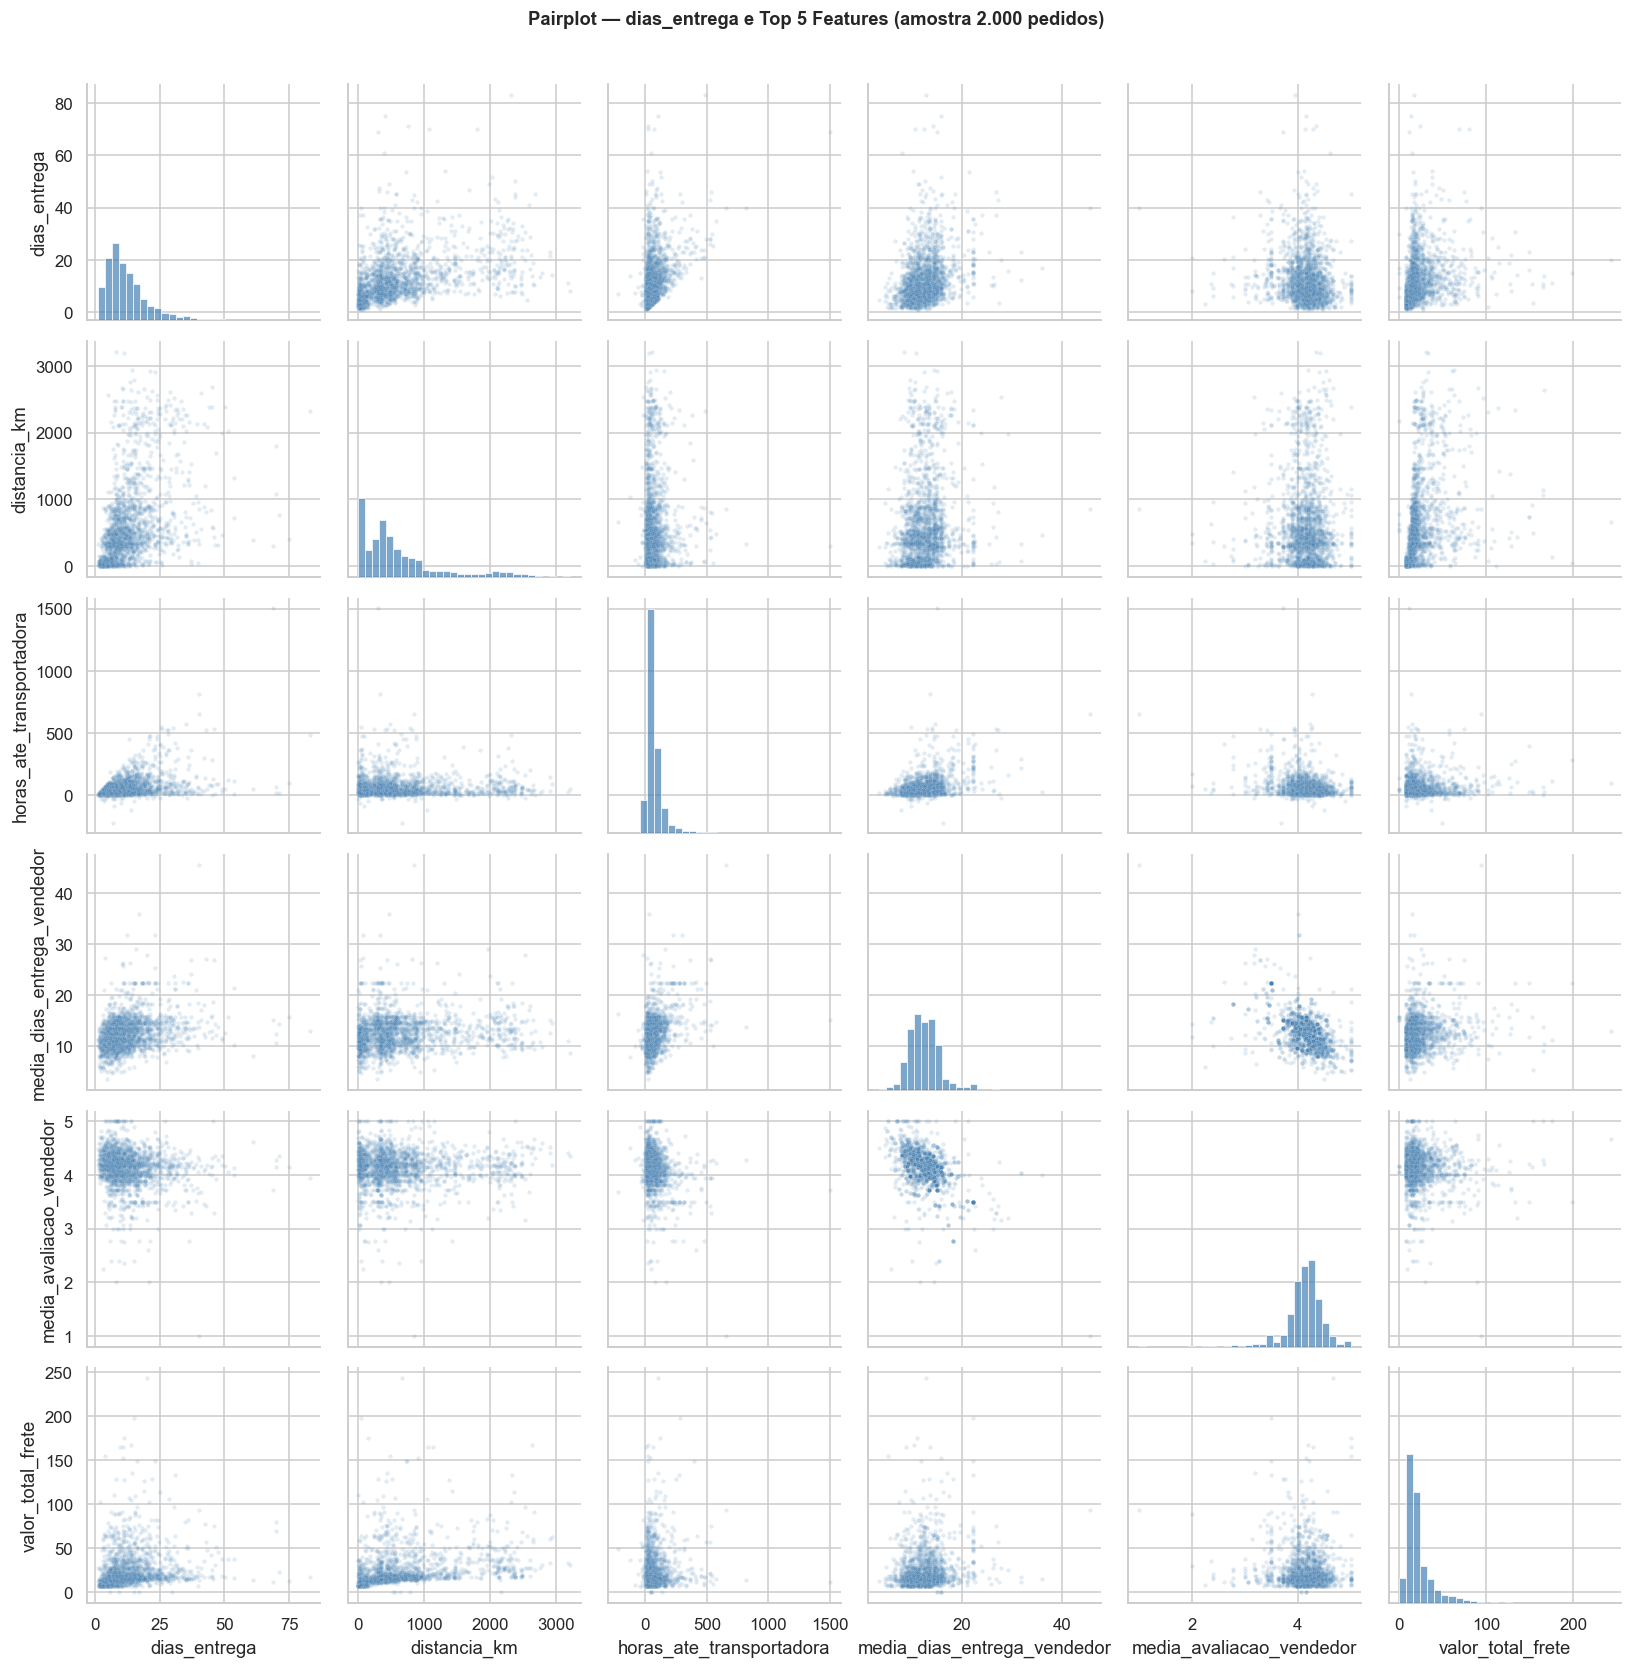

In [19]:
# Top 5 features mais correlacionadas com o target
top5 = (df[colunas_num].corr()['dias_entrega']
        .drop('dias_entrega')
        .sort_values(key=abs, ascending=False)
        .head(5).index.tolist())

print("Top 5 features mais correlacionadas com dias_entrega:")
for f in top5:
    r = df[['dias_entrega', f]].corr().iloc[0,1]
    print(f"  {f:<35s}  r = {r:+.3f}")

cols_plot = ['dias_entrega'] + top5
amostra   = df[cols_plot].sample(2000, random_state=42)

g = sns.pairplot(amostra, diag_kind='hist', plot_kws={'alpha': 0.15, 's': 8, 'color': 'steelblue'},
                 diag_kws={'color': 'steelblue', 'alpha': 0.7, 'bins': 30})
g.figure.suptitle("Pairplot — dias_entrega e Top 5 Features (amostra 2.000 pedidos)",
                  y=1.01, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 19. Recomendacoes para o Modelo

In [20]:
# Gera automaticamente o relatorio com base nos dados reais
corr_vals  = df[colunas_num].corr()['dias_entrega'].drop('dias_entrega')
fortes     = corr_vals[corr_vals.abs() >= 0.4].sort_values(key=abs, ascending=False)
moderadas  = corr_vals[(corr_vals.abs() >= 0.2) & (corr_vals.abs() < 0.4)].sort_values(key=abs, ascending=False)
fracas     = corr_vals[corr_vals.abs() < 0.2].sort_values(key=abs, ascending=False)

skew_vals  = df[colunas_num].skew()
altas_skew = skew_vals[skew_vals.abs() > 1].sort_values(key=abs, ascending=False)

out_critico = []
for col in colunas_num:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    pct = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).mean() * 100
    if pct > 5:
        out_critico.append(f"{col} ({pct:.1f}%)")

pares_multi = []
cm = df[colunas_num].corr()
for i in range(len(colunas_num)):
    for j in range(i+1, len(colunas_num)):
        if abs(cm.iloc[i,j]) >= 0.7:
            pares_multi.append(f"{colunas_num[i]} x {colunas_num[j]} (r={cm.iloc[i,j]:.2f})")

print("=" * 62)
print("  RECOMENDACOES PARA O MODELO")
print("=" * 62)

print("\n1. FEATURES MAIS IMPORTANTES (correlacao forte com target)")
if len(fortes):
    for f, v in fortes.items(): print(f"   {f:<35s} r={v:+.3f}")
else:
    print("   Nenhuma feature com correlacao forte encontrada.")

print("\n2. FEATURES SECUNDARIAS (correlacao moderada)")
if len(moderadas):
    for f, v in moderadas.items(): print(f"   {f:<35s} r={v:+.3f}")
else:
    print("   Nenhuma.")

print("\n3. FEATURES COM BAIXO PODER PREDITIVO (correlacao fraca)")
if len(fracas):
    for f, v in fracas.items(): print(f"   {f:<35s} r={v:+.3f}")

print("\n4. FEATURES QUE PRECISAM DE TRANSFORMACAO (skewness alto)")
if len(altas_skew):
    for f, v in altas_skew.items():
        print(f"   {f:<35s} skew={v:.2f}  -> recomenda log ou sqrt")
else:
    print("   Nenhuma feature com skewness critico.")

print("\n5. FEATURES COM MUITOS OUTLIERS (>5%)")
if out_critico:
    for item in out_critico: print(f"   {item}")
else:
    print("   Nenhuma feature critica encontrada.")

print("\n6. MULTICOLINEARIDADE")
if pares_multi:
    for par in pares_multi: print(f"   {par}")
    print("   -> Considere remover uma feature de cada par.")
else:
    print("   Nenhum par redundante encontrado.")

print("\n7. VARIAVEIS CATEGORICAS")
print("   Aplicar encoding antes do modelo:")
print("   - categoria_produto -> Label Encoding ou Target Encoding")
print("   - tipo_pagamento    -> One-Hot Encoding (poucos valores)")
print("   - regiao_cliente    -> One-Hot Encoding")
print("   - customer_state    -> Target Encoding (muitos valores)")

print("\n" + "=" * 62)

  RECOMENDACOES PARA O MODELO

1. FEATURES MAIS IMPORTANTES (correlacao forte com target)
   distancia_km                        r=+0.409
   horas_ate_transportadora            r=+0.402

2. FEATURES SECUNDARIAS (correlacao moderada)
   media_dias_entrega_vendedor         r=+0.358

3. FEATURES COM BAIXO PODER PREDITIVO (correlacao fraca)
   media_avaliacao_vendedor            r=-0.180
   valor_total_frete                   r=+0.175
   proporcao_frete                     r=+0.086
   horas_ate_aprovacao                 r=+0.086
   peso_total_gramas                   r=+0.074
   valor_pago_total                    r=+0.070
   volume_total_cm3                    r=+0.065
   valor_total_pedido                  r=+0.055
   mes_compra                          r=-0.055
   qtd_parcelas                        r=+0.054
   dia_semana_compra                   r=+0.032
   media_qtd_fotos                     r=-0.028
   total_pedidos_vendedor              r=+0.027
   qtd_itens                         